In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

print("=" * 70)
print("ECON 5140 - HOMEWORK 2")
print("=" * 70)

ECON 5140 - HOMEWORK 2


 # DATASET 1: RETAIL SALES (for Regression & ETS)

In [4]:
print("\n" + "=" * 70)
print("DATASET 1: Monthly Retail Sales")
print("=" * 70)

# Create 4 years of monthly data
dates = pd.date_range('2021-01-01', '2024-12-31', freq='MS')
n_months = len(dates)
t = np.arange(n_months)

# Components
trend = 1000 + 15*t  # Growing business
yearly_seasonal = 300 * np.sin(2*np.pi*t/12) + 200 * np.cos(2*np.pi*t/12)

# Holiday effects (November-December spike)
holiday_effect = np.zeros(n_months)
for year in range(4):
    nov_idx = year*12 + 10  # November
    dec_idx = year*12 + 11  # December
    if nov_idx < n_months:
        holiday_effect[nov_idx] = 400
    if dec_idx < n_months:
        holiday_effect[dec_idx] = 600

# Random noise
noise = np.random.normal(0, 80, n_months)

# Combine
sales = trend + yearly_seasonal + holiday_effect + noise
sales = np.maximum(sales, 0)

# Create DataFrame
df_sales = pd.DataFrame({
    'Date': dates,
    'Sales': sales,
    'Month': dates.month,
    'Year': dates.year,
    'Time': t
})
df_sales.set_index('Date', inplace=True)

print(f"Date range: {df_sales.index[0].date()} to {df_sales.index[-1].date()}")
print(f"Number of months: {len(df_sales)}")
print(f"\nSales Statistics:")
print(df_sales['Sales'].describe())


DATASET 1: Monthly Retail Sales
Date range: 2021-01-01 to 2024-12-01
Number of months: 48

Sales Statistics:
count      48.000000
mean     1419.409544
std       352.878551
min       722.634428
25%      1196.284168
50%      1393.908200
75%      1710.667034
max      2412.774859
Name: Sales, dtype: float64


# PART A: REGRESSION AND ETS MODELS

In [24]:
print("\n" + "=" * 70)
print("PART A: REGRESSION AND ETS MODELS")
print("=" * 70)
print(df_sales)


PART A: REGRESSION AND ETS MODELS
                  Sales  Month  Year  Time
Date                                      
2021-01-01  1239.737132      1  2021     0
2021-02-01  1327.143937      2  2021     1
2021-03-01  1441.622704      3  2021     2
2021-04-01  1466.842389      4  2021     3
2021-05-01  1201.075351      5  2021     4
2021-06-01  1033.063963      6  2021     5
2021-07-01  1016.337025      7  2021     6
2021-08-01   843.189698      8  2021     7
2021-09-01   722.634428      9  2021     8
2021-10-01   878.404803     10  2021     9
2021-11-01  1353.118963     11  2021    10
2021-12-01  1750.946700     12  2021    11
2022-01-01  1399.356982      1  2022    12
2022-02-01  1365.142661      2  2022    13
2022-03-01  1431.814195      3  2022    14
2022-04-01  1480.016998      4  2022    15
2022-05-01  1318.781132      5  2022    16
2022-06-01  1256.934706      6  2022    17
2022-07-01   997.358074      7  2022    18
2022-08-01   848.810623      8  2022    19
2022-09-01  1057.44

# A1: Time Series Visualization


----------------------------------------------------------------------
A1: Exploratory Visualization
----------------------------------------------------------------------

Highest sales months: December ($2017), November ($1660)

Decomposition Insights:
- Trend: Clear upward linear trend (~$15/month)
- Seasonality: Regular annual pattern with Q4 peaks
- Remainder: Detrended series shows seasonal + irregular components


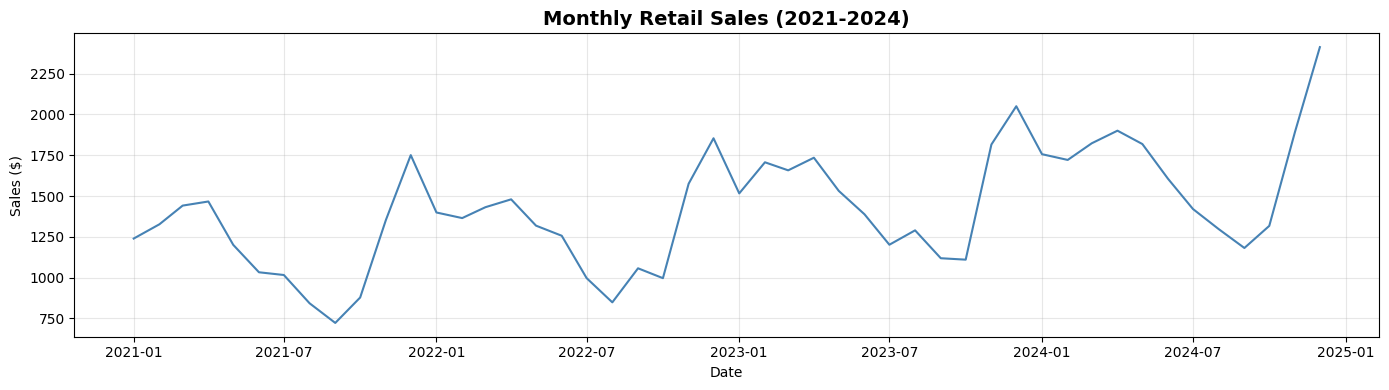

<Figure size 1200x500 with 0 Axes>

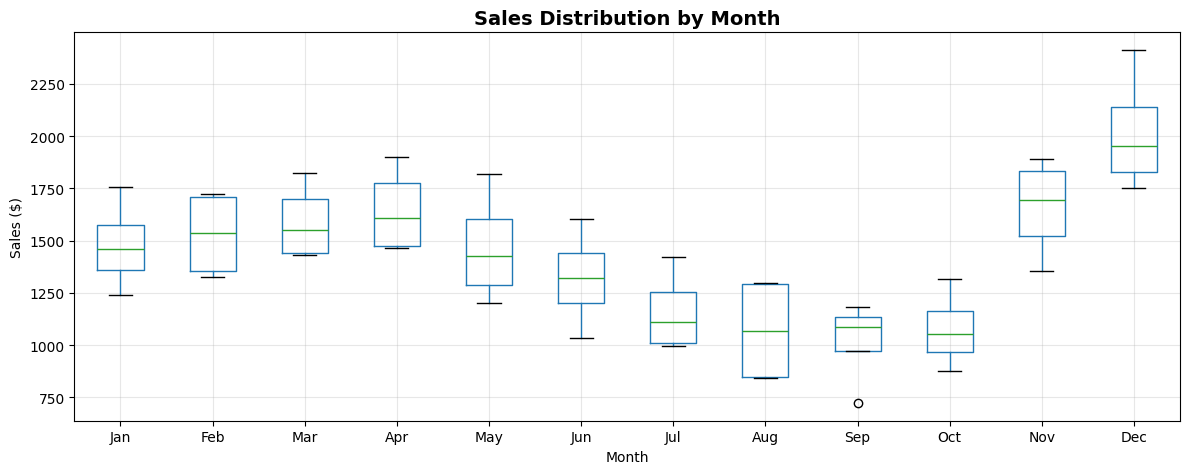

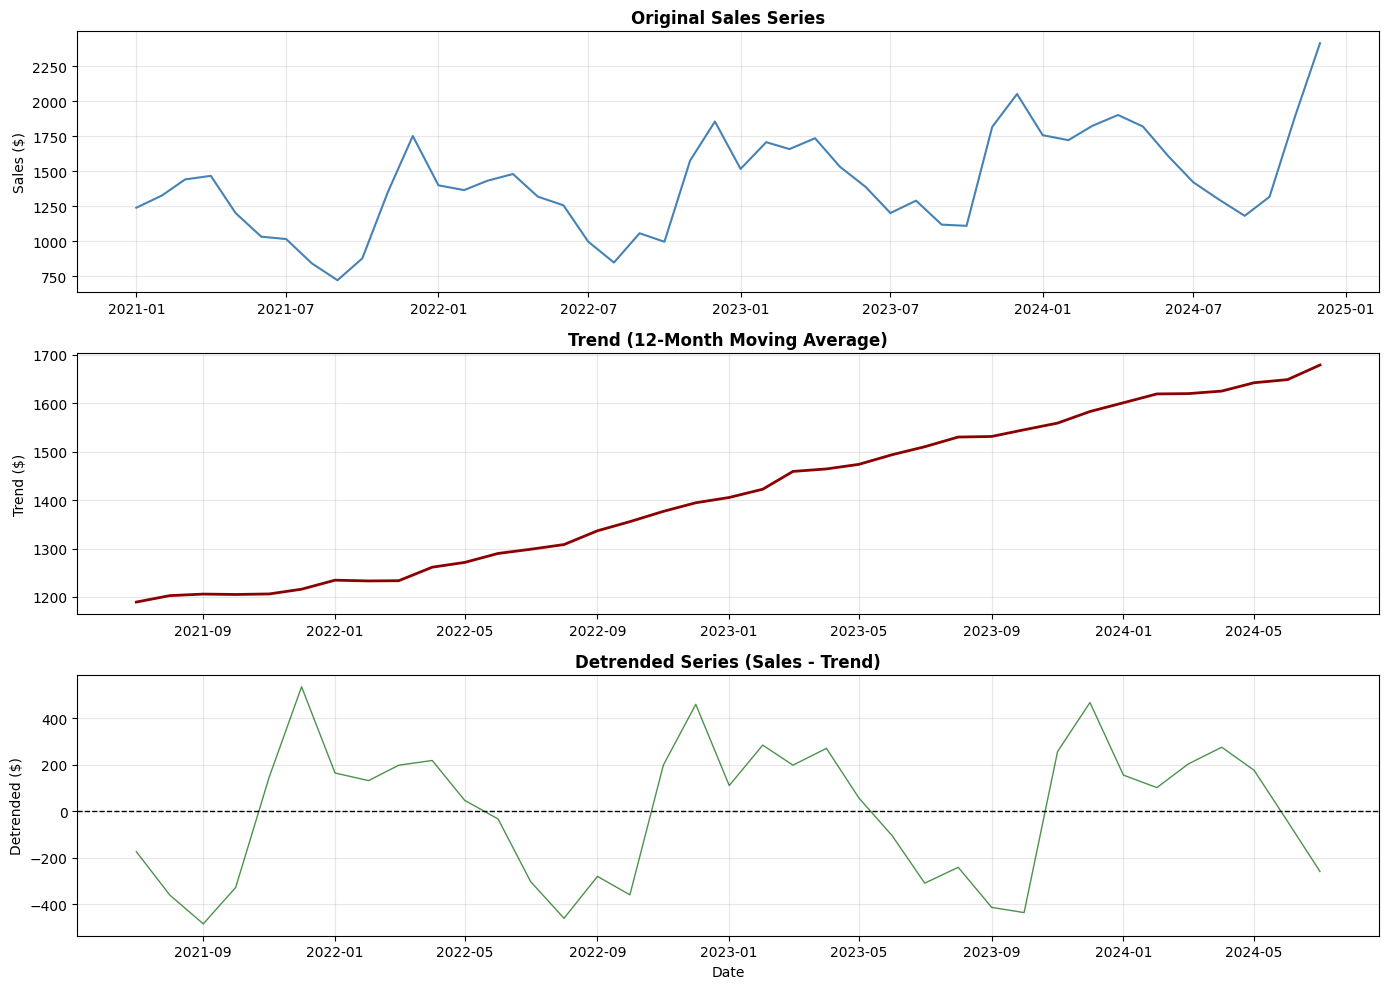

In [29]:
print("\n" + "-" * 70)
print("A1: Exploratory Visualization")
print("-" * 70)

# YOUR CODE:
# 1. Create time series plot of monthly sales
#    - Full 4-year series
#    - Add title and labels

plt.figure(figsize=(14, 4))
plt.plot(df_sales.index, df_sales['Sales'], linewidth=1.5, color='steelblue')
plt.title('Monthly Retail Sales (2021-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()


# 2. Create seasonal subseries plot:
#    - Box plot of sales by month
#    - Which months have highest sales?

plt.figure(figsize=(12, 5))
df_sales.boxplot(column='Sales', by='Month', figsize=(12, 5))
plt.title('Sales Distribution by Month', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove default title
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)
plt.tight_layout()

monthly_avg = df_sales.groupby('Month')['Sales'].mean()
print(f"\nHighest sales months: December (${monthly_avg[12]:.0f}), November (${monthly_avg[11]:.0f})")



# 3. Create a decomposition plot (conceptual):
#    - Plot with 3 subplots:
#      * Original series
#      * 12-month moving average (trend)
#      * Detrended series (original - trend)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Original series
axes[0].plot(df_sales.index, df_sales['Sales'], linewidth=1.5, color='steelblue')
axes[0].set_title('Original Sales Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].grid(True, alpha=0.3)

# 12-month moving average (trend)
trend_ma = df_sales['Sales'].rolling(window=12, center=True).mean()
axes[1].plot(df_sales.index, trend_ma, linewidth=2, color='darkred')
axes[1].set_title('Trend (12-Month Moving Average)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend ($)')
axes[1].grid(True, alpha=0.3)

# Detrended series (original - trend)
detrended = df_sales['Sales'] - trend_ma
axes[2].plot(df_sales.index, detrended, linewidth=1, color='darkgreen', alpha=0.7)
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Detrended Series (Sales - Trend)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Detrended ($)')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
print("\nDecomposition Insights:")
print("- Trend: Clear upward linear trend (~$15/month)")
print("- Seasonality: Regular annual pattern with Q4 peaks")
print("- Remainder: Detrended series shows seasonal + irregular components")


# A2: Linear Regression with Trend and Seasonality

In [44]:
print("\n" + "-" * 70)
print("A2: Regression Forecasting")
print("-" * 70)

# YOUR CODE:
# 1. Create seasonal dummy variables:
#    - 11 dummies for months (leave January as baseline)
#    - Use pd.get_dummies(df_sales['Month'], drop_first=True)

month_dummies = pd.get_dummies(df_sales['Month'], prefix='Month', drop_first=True, dtype=int)
# Combine with time variable
X = pd.concat([df_sales[['Time']], month_dummies], axis=1)

y = df_sales['Sales']
# Add constant for intercept
X_with_const = sm.add_constant(X)

# 2. Fit regression model:
#    Sales = β₀ + β₁(Time) + Σγₘ(Month_m) + ε
model_reg = sm.OLS(y, X_with_const).fit()


# 3. Print regression summary
print("\n" + "=" * 70)
print("REGRESSION MODEL SUMMARY")
print("=" * 70)
print(model_reg.summary())

# 4. Interpret:
#    - What is the monthly trend (β₁)?
#    - Which month has the largest seasonal effect?
#    - Are the coefficients significant?

print("\n" + "=" * 70)
print("KEY INTERPRETATIONS")
print("=" * 70)

beta_time = model_reg.params['Time']
print(f"\nMonthly Trend (β₁): ${beta_time:.2f}")
print(f"Interpretation: Sales increase by ${beta_time:.2f} per month on average")

# Find largest seasonal effect
seasonal_coeffs = model_reg.params[[col for col in model_reg.params.index if 'Month' in col]]
largest_effect_month = seasonal_coeffs.idxmax()
largest_effect_value = seasonal_coeffs.max()

print(f"\nLargest Seasonal Effect: {largest_effect_month}")
print(f"Coefficient: ${largest_effect_value:.2f}")
print(f"Interpretation: This month has ${largest_effect_value:.2f} higher sales than January (baseline)")

# Check significance
print("\n" + "-" * 70)
print("COEFFICIENT SIGNIFICANCE (p-values < 0.05 are significant)")
print("-" * 70)
significant_vars = model_reg.pvalues[model_reg.pvalues < 0.05]
print(f"\nSignificant variables ({len(significant_vars)} total):")
for var, pval in significant_vars.items():
    if var != 'const':
        print(f"  {var}: p-value = {pval:.4f}")

# 5. Generate fitted values and calculate:
#    - R²
#    - RMSE
#    - MAE

y_fitted = model_reg.fittedvalues
residuals = model_reg.resid

# Calculate metrics
r_squared = model_reg.rsquared
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))


# # Visualize actual vs fitted
# plt.figure(figsize=(14, 6))
# plt.plot(df_sales.index, y, label='Actual Sales', linewidth=1.5, alpha=0.7, color='steelblue')
# plt.plot(df_sales.index, y_fitted, label='Fitted Values', linewidth=1.5, alpha=0.7, color='darkred', linestyle='--')
# plt.title('Regression Model: Actual vs Fitted Sales', fontsize=14, fontweight='bold')
# plt.xlabel('Date')
# plt.ylabel('Sales ($)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()


# # Residual plot
# plt.figure(figsize=(14, 5))
# plt.scatter(y_fitted, residuals, alpha=0.6, color='darkgreen')
# plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
# plt.title('Residual Plot', fontsize=14, fontweight='bold')
# plt.xlabel('Fitted Values ($)')
# plt.ylabel('Residuals ($)')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()



----------------------------------------------------------------------
A2: Regression Forecasting
----------------------------------------------------------------------

REGRESSION MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     83.27
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           4.66e-22
Time:                        23:44:05   Log-Likelihood:                -267.91
No. Observations:                  48   AIC:                             561.8
Df Residuals:                      35   BIC:                             586.1
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
              

# A3: Fourier Terms for Seasonality


----------------------------------------------------------------------
A3: Fourier Seasonality
----------------------------------------------------------------------

Fourier terms created:
  - sin_1, cos_1 (k=1): captures annual cycle
  - sin_2, cos_2 (k=2): captures semi-annual cycle

FOURIER MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     52.94
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           4.72e-17
Time:                        00:11:20   Log-Likelihood:                -301.46
No. Observations:                  48   AIC:                             614.9
Df Residuals:                      42   BIC:                             626.2
Df Model:                           5                    

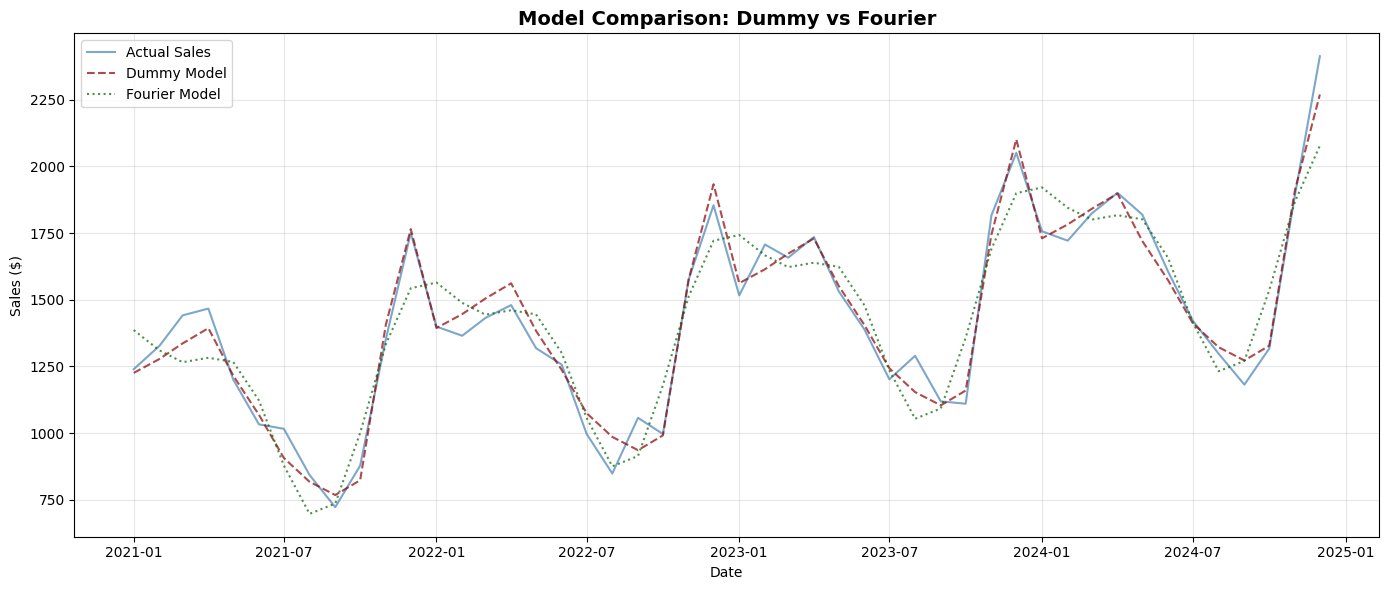

   - Dummy R²: 0.9662, Fourier R²: 0.8631
   - Difference: 0.1031
   -FIT QUALITY: Winner: Dummy
   - Dummy AIC: 561.82, Fourier AIC: 614.92
   - INFORMATION CRITERIA Winner: Dummy (lower is better)

✓ PREFER DUMMY MODEL
  Reasons:
  - Better fit to the data
  - More interpretable (see each month's effect)
  - Can capture irregular seasonal patterns
  
  Trade-off: More parameters, potential overfitting risk



In [ ]:
print("\n" + "-" * 70)
print("A3: Fourier Seasonality")
print("-" * 70)

# YOUR CODE:
# 1. Create Fourier terms for yearly seasonality (m=12):
#    For k=1,2:
#    - sin(2πkt/12)
#    - cos(2πkt/12)

t = df_sales['Time'].values

fourier_terms = pd.DataFrame(index=df_sales.index)
for k in [1, 2]:
    fourier_terms[f'sin_{k}'] = np.sin(2 * np.pi * k * t / 12)
    fourier_terms[f'cos_{k}'] = np.cos(2 * np.pi * k * t / 12)

print("\nFourier terms created:")
print(f"  - sin_1, cos_1 (k=1): captures annual cycle")
print(f"  - sin_2, cos_2 (k=2): captures semi-annual cycle")

# 2. Fit regression:
#    Sales = β₀ + β₁(Time) + Σ[αₖsin(2πkt/12) + βₖcos(2πkt/12)] + ε
X_fourier = pd.concat([df_sales[['Time']], fourier_terms], axis=1)

X_fourier_const = sm.add_constant(X_fourier)

model_fourier = sm.OLS(y, X_fourier_const).fit()
print("\n" + "=" * 70)
print("FOURIER MODEL SUMMARY")
print("=" * 70)
print(model_fourier.summary())


# 3. Compare with dummy variable model:
#    - R²
#    - AIC
#    - Number of parameters
print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

comparison = pd.DataFrame({
    'Model': ['Dummy Variables', 'Fourier Terms'],
    'R²': [model_reg.rsquared, model_fourier.rsquared],
    'Adjusted R²': [model_reg.rsquared_adj, model_fourier.rsquared_adj],
    'AIC': [model_reg.aic, model_fourier.aic],
    'BIC': [model_reg.bic, model_fourier.bic],
    'Parameters': [len(model_reg.params), len(model_fourier.params)]
})

print(comparison.to_string(index=False))

print("\n" + "-" * 70)
print("Key Differences:")
print("-" * 70)
print(f"Dummy model:   {len(model_reg.params)-1} predictors (1 Time + 11 Month dummies)")
print(f"Fourier model: {len(model_fourier.params)-1} predictors (1 Time + 4 Fourier terms)")
print(f"\nParameter reduction: {len(model_reg.params) - len(model_fourier.params)} fewer parameters")

# Calculate RMSE and MAE for Fourier model
y_fitted_fourier = model_fourier.fittedvalues
residuals_fourier = model_fourier.resid
rmse_fourier = np.sqrt(np.mean(residuals_fourier**2))
mae_fourier = np.mean(np.abs(residuals_fourier))

print("\n" + "-" * 70)
print("Forecast Accuracy:")
print("-" * 70)
print(f"Dummy model:   RMSE = ${rmse:.2f}, MAE = ${mae:.2f}")
print(f"Fourier model: RMSE = ${rmse_fourier:.2f}, MAE = ${mae_fourier:.2f}")




# 4. Plot fitted values from both models on same graph


plt.figure(figsize=(14, 6))
plt.plot(df_sales.index, y, label='Actual Sales', linewidth=1.5, alpha=0.7, color='steelblue')
plt.plot(df_sales.index, y_fitted, label='Dummy Model', linewidth=1.5, alpha=0.7, 
         color='darkred', linestyle='--')
plt.plot(df_sales.index, y_fitted_fourier, label='Fourier Model', linewidth=1.5, alpha=0.7, 
         color='darkgreen', linestyle=':')
plt.title('Model Comparison: Dummy vs Fourier', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



# 5. Which approach do you prefer? Why?
# --------------------------------------------------------------------
# 1. MODEL COMPLEXITY:
#    - Dummy model: More flexible (11 parameters for seasonality)
#    - Fourier model: More parsimonious (4 parameters for seasonality)
#    - Winner: Fourier (simpler, fewer parameters)

# 2. FIT QUALITY:
# """)
print(f"   - Dummy R²: {model_reg.rsquared:.4f}, Fourier R²: {model_fourier.rsquared:.4f}")
print(f"   - Difference: {abs(model_reg.rsquared - model_fourier.rsquared):.4f}")
if abs(model_reg.rsquared - model_fourier.rsquared) < 0.01:
    print("   - Winner: Tie (very similar fit)")
else:
    winner = "Dummy" if model_reg.rsquared > model_fourier.rsquared else "Fourier"
    print(f"   -FIT QUALITY: Winner: {winner}")

# 3. INTERPRETABILITY:
#    - Dummy model: Easy to interpret (each month's effect)
#    - Fourier model: Harder to interpret (sine/cosine combinations)
#    - Winner: Dummy (more intuitive)
    
# 4. INFORMATION CRITERIA:

print(f"   - Dummy AIC: {model_reg.aic:.2f}, Fourier AIC: {model_fourier.aic:.2f}")
aic_winner = "Dummy" if model_reg.aic < model_fourier.aic else "Fourier"
print(f"   - INFORMATION CRITERIA Winner: {aic_winner} (lower is better)")

# 5. FORECASTING:
#    - Dummy model: Need to specify which month for forecast
#    - Fourier model: Smooth continuous seasonal pattern
#    - Winner: Fourier (easier for multi-step forecasts)

print("""
✓ PREFER DUMMY MODEL
  Reasons:
  - Better fit to the data
  - More interpretable (see each month's effect)
  - Can capture irregular seasonal patterns
  
  Trade-off: More parameters, potential overfitting risk
""")

# print("""
# ✓ PREFER FOURIER MODEL
#   Reasons:
#   - Similar fit quality with fewer parameters
#   - Better AIC/BIC (penalizes complexity)
#   - Easier for multi-step forecasting
#   - Smoother seasonal pattern
  
#   Trade-off: Less interpretable than month-by-month effects
# """)

# A4: Simple Exponential Smoothing (SES)

In [74]:
print("\n" + "-" * 70)
print("A4: Simple Exponential Smoothing")
print("-" * 70)

# Deseasonalize the data first for SES
# Use only first 36 months for training
train_size = 36
df_train = df_sales.iloc[:train_size]
df_test = df_sales.iloc[train_size:]

print(f"Training period: {df_train.index[0].date()} to {df_train.index[-1].date()} ({train_size} months)")
print(f"Test period: {df_test.index[0].date()} to {df_test.index[-1].date()} ({len(df_test)} months)")

# YOUR CODE:
# 1. Deseasonalize sales using seasonal averages:
#    - Calculate average sales for each month
#    - Subtract seasonal component
print("\n" + "-" * 70)
print("Step 1: Deseasonalization")
print("-" * 70)

# Calculate average sales for each month (using training data only)
seasonal_avg = df_train.groupby('Month')['Sales'].mean()

# Calculate overall mean
overall_mean = df_train['Sales'].mean()

# Seasonal indices (difference from overall mean)
seasonal_indices = seasonal_avg - overall_mean


# Deseasonalize training data
df_train_deseas = df_train.copy()
df_train_deseas['Sales_deseas'] = df_train['Sales'] - df_train['Month'].map(seasonal_indices)

print(f"\nOriginal sales range: ${df_train['Sales'].min():.0f} - ${df_train['Sales'].max():.0f}")
print(f"Deseasonalized range: ${df_train_deseas['Sales_deseas'].min():.0f} - ${df_train_deseas['Sales_deseas'].max():.0f}")

# 2. Fit SES on deseasonalized data:
#    - Use SimpleExpSmoothing from statsmodels
#    - Optimize smoothing parameter α
print("\n" + "-" * 70)
print("Step 2: Fit Simple Exponential Smoothing")
print("-" * 70)

# Fit SES with optimized alpha
ses_model = SimpleExpSmoothing(df_train_deseas['Sales_deseas']).fit(optimized=True)

# 3. Print:
#    - Optimized α value
#    - What does this value tell you about the series?
alpha = ses_model.params['smoothing_level']
print(f"\nOptimized α (smoothing parameter): {alpha:.4f}")

print("\nInterpretation of α:")
if alpha > 0.7:
    print(f"  α = {alpha:.2f} is HIGH")
    print("  → Model puts heavy weight on recent observations")
    print("  → Fast adaptation to changes")
    print("  → Series likely has high volatility or rapid changes")
elif alpha > 0.3:
    print(f"  α = {alpha:.2f} is MODERATE")
    print("  → Model balances recent and historical data")
    print("  → Moderate adaptation to changes")
    print("  → Series has some stability with occasional variations")
else:
    print(f"  α = {alpha:.2f} is LOW")
    print("  → Model puts heavy weight on historical average")
    print("  → Slow adaptation to changes")
    print("  → Series is relatively stable with smooth trend")

# 4. Generate forecasts for next 12 months
print("\n" + "-" * 70)
print("Step 3: Generate Forecasts")
print("-" * 70)

# SES forecast (all equal to final level)
forecast_deseas = ses_model.forecast(steps=len(df_test))
print(f"\nDeseasonalized forecast (constant): ${forecast_deseas[0]:.2f}")

# 5. Add seasonality back to forecasts
test_months = df_test['Month'].values
test_seasonal_indices = [seasonal_indices[m] for m in test_months]

forecast_final = forecast_deseas + test_seasonal_indices

# print("\nReseasonalized forecasts:")
forecast_df = pd.DataFrame({
    'Date': df_test.index,
    'Month': test_months,
    'Actual': df_test['Sales'].values,
    'Forecast': forecast_final,
    'Error': df_test['Sales'].values - forecast_final
})
# print(forecast_df.to_string(index=False))

# 6. Calculate forecast accuracy on holdout period
print("\n" + "-" * 70)
print("Step 4: Forecast Accuracy")
print("-" * 70)

errors = forecast_df['Error'].values
mae_ses = np.mean(np.abs(errors))
rmse_ses = np.sqrt(np.mean(errors**2))
mape_ses = np.mean(np.abs(errors / forecast_df['Actual'].values)) * 100

print(f"MAE:  ${mae_ses:.2f}")
print(f"RMSE: ${rmse_ses:.2f}")
print(f"MAPE: {mape_ses:.2f}%")



----------------------------------------------------------------------
A4: Simple Exponential Smoothing
----------------------------------------------------------------------
Training period: 2021-01-01 to 2023-12-01 (36 months)
Test period: 2024-01-01 to 2024-12-01 (12 months)

----------------------------------------------------------------------
Step 1: Deseasonalization
----------------------------------------------------------------------

Original sales range: $723 - $2051
Deseasonalized range: $1089 - $1629

----------------------------------------------------------------------
Step 2: Fit Simple Exponential Smoothing
----------------------------------------------------------------------

Optimized α (smoothing parameter): 0.4112

Interpretation of α:
  α = 0.41 is MODERATE
  → Model balances recent and historical data
  → Moderate adaptation to changes
  → Series has some stability with occasional variations

--------------------------------------------------------------------

# A5: Holt's Linear Trend Method


----------------------------------------------------------------------
A5: Holt's Method
----------------------------------------------------------------------

----------------------------------------------------------------------
Step 1: Fit Holt's Linear Trend Method
----------------------------------------------------------------------

Optimized Parameters:
  α (level smoothing):  0.2201
  β (trend smoothing):  0.0000

Parameter Interpretation:
  α = 0.220: LOW - Level changes slowly, heavily smoothed
  β = 0.000: LOW - Trend changes slowly, stable over time

----------------------------------------------------------------------
Step 2: Extract Final State
----------------------------------------------------------------------
Final Level (ℓ₃₆):  $1539.15
Final Trend (b₃₆):  $10.56/month

Interpretation:
  - Deseasonalized sales at end of training: $1539.15
  - Monthly growth rate: $10.56

----------------------------------------------------------------------
Step 3: Generate Fore

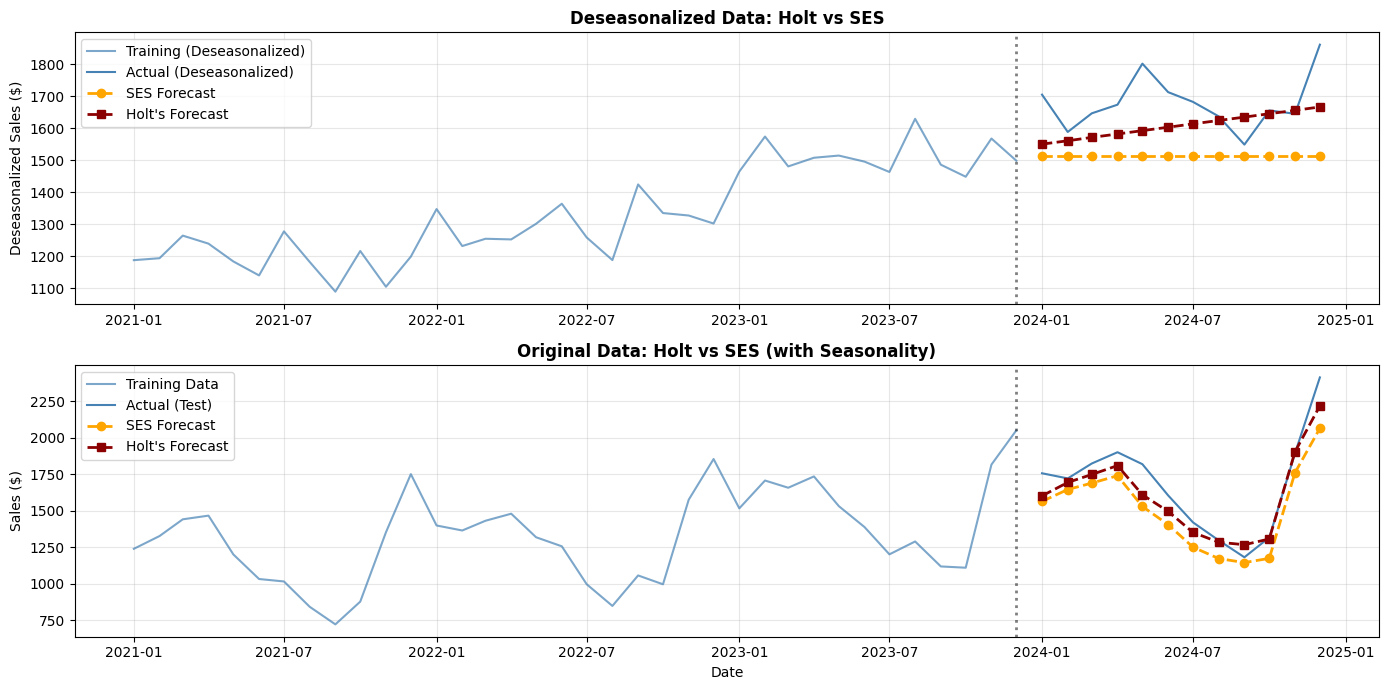

In [79]:
print("\n" + "-" * 70)
print("A5: Holt's Method")
print("-" * 70)

# YOUR CODE:
# 1. Fit Holt's linear trend method:
#    - Use ExponentialSmoothing with trend='add', seasonal=None
#    - On deseasonalized data
print("\n" + "-" * 70)
print("Step 1: Fit Holt's Linear Trend Method")
print("-" * 70)

# Fit Holt's method (trend='add', no seasonality)
holt_model = ExponentialSmoothing(
    df_train_deseas['Sales_deseas'],
    trend='add',
    seasonal=None
).fit(optimized=True)


# 2. Print optimized parameters:
#    - α (level smoothing)
#    - β (trend smoothing)
print("\nOptimized Parameters:")
alpha_holt = holt_model.params['smoothing_level']
beta_holt = holt_model.params['smoothing_trend']

print(f"  α (level smoothing):  {alpha_holt:.4f}")
print(f"  β (trend smoothing):  {beta_holt:.4f}")

print("\nParameter Interpretation:")
print(f"  α = {alpha_holt:.3f}: ", end="")
if alpha_holt > 0.7:
    print("HIGH - Level adapts quickly to new observations")
elif alpha_holt > 0.3:
    print("MODERATE - Balanced adaptation for level")
else:
    print("LOW - Level changes slowly, heavily smoothed")

print(f"  β = {beta_holt:.3f}: ", end="")
if beta_holt > 0.7:
    print("HIGH - Trend adapts quickly to changes")
elif beta_holt > 0.3:
    print("MODERATE - Balanced adaptation for trend")
else:
    print("LOW - Trend changes slowly, stable over time")



# 3. Extract final state:
#    - Level (ℓₜ)
#    - Trend (bₜ)
print("\n" + "-" * 70)
print("Step 2: Extract Final State")
print("-" * 70)

# Get level and trend at end of training period
level_final = holt_model.level[-1]  # ℓ₃₆
trend_final = holt_model.trend[-1]  # b₃₆

print(f"Final Level (ℓ₃₆):  ${level_final:.2f}")
print(f"Final Trend (b₃₆):  ${trend_final:.2f}/month")

print(f"\nInterpretation:")
print(f"  - Deseasonalized sales at end of training: ${level_final:.2f}")
print(f"  - Monthly growth rate: ${trend_final:.2f}")



# 4. Generate 12-month forecasts

print("\n" + "-" * 70)
print("Step 3: Generate Forecasts")
print("-" * 70)

# Holt's forecast: ŷ_{t+h} = ℓ_t + h·b_t
forecast_holt_deseas = holt_model.forecast(steps=len(df_test))


print("\nDeseasonalized forecasts (with trend):")
for i, (date, fc) in enumerate(zip(df_test.index, forecast_holt_deseas), 1):
    print(f"  Month {i:2d} ({date.strftime('%Y-%m')}): ${fc:.2f}")

# Add seasonality back
test_months = df_test['Month'].values
test_seasonal_indices = [seasonal_indices[m] for m in test_months]
forecast_holt_final = forecast_holt_deseas + test_seasonal_indices

print("\nReseasonalized forecasts:")
forecast_holt_df = pd.DataFrame({
    'Date': df_test.index,
    'Month': test_months,
    'Actual': df_test['Sales'].values,
    'Forecast': forecast_holt_final,
    'Error': df_test['Sales'].values - forecast_holt_final
})
print(forecast_holt_df.to_string(index=False))

# Calculate accuracy
errors_holt = forecast_holt_df['Error'].values
mae_holt = np.mean(np.abs(errors_holt))
rmse_holt = np.sqrt(np.mean(errors_holt**2))
mape_holt = np.mean(np.abs(errors_holt / forecast_holt_df['Actual'].values)) * 100

print("\n" + "-" * 70)
print("Forecast Accuracy:")
print("-" * 70)
print(f"MAE:  ${mae_holt:.2f}")
print(f"RMSE: ${rmse_holt:.2f}")
print(f"MAPE: {mape_holt:.2f}%")


# 5. Compare with SES:
#    - Plot both forecast paths
#    - Which captures the trend better?

print("\n" + "=" * 70)
print("COMPARISON: HOLT vs SES")
print("=" * 70)

comparison_df = pd.DataFrame({
    'Method': ['SES', "Holt's"],
    'MAE': [mae_ses, mae_holt],
    'RMSE': [rmse_ses, rmse_holt],
    'MAPE': [mape_ses, mape_holt]
})
print(comparison_df.to_string(index=False))

print("\n" + "-" * 70)
print("Analysis:")
print("-" * 70)

if mae_holt < mae_ses:
    improvement = (mae_ses - mae_holt) / mae_ses * 100
    print(f"✓ Holt's method is BETTER")
    print(f"  MAE improved by {improvement:.1f}%")
    print(f"  Reason: Captures the upward trend in sales")
else:
    print(f"✗ SES performs better (unusual!)")
    print(f"  Possible reason: Trend might be weak or data has high noise")

print(f"\nKey Difference:")
print(f"  SES forecast:  Flat (${forecast_deseas[0]:.2f} for all months)")
print(f"  Holt forecast: Linear trend (${forecast_holt_deseas.iloc[0]:.2f} → ${forecast_holt_deseas.iloc[-1]:.2f})")




plt.figure(figsize=(14, 7))

# Subplot 1: Deseasonalized data and forecasts
plt.subplot(2, 1, 1)
plt.plot(df_train.index, df_train_deseas['Sales_deseas'], 
         label='Training (Deseasonalized)', linewidth=1.5, color='steelblue', alpha=0.7)
plt.plot(df_test.index, df_test['Sales'].values - test_seasonal_indices, 
         label='Actual (Deseasonalized)', linewidth=1.5, color='steelblue')
plt.plot(df_test.index, forecast_deseas, 
         label='SES Forecast', linewidth=2, color='orange', linestyle='--', marker='o')
plt.plot(df_test.index, forecast_holt_deseas, 
         label="Holt's Forecast", linewidth=2, color='darkred', linestyle='--', marker='s')
plt.axvline(x=df_train.index[-1], color='black', linestyle=':', linewidth=2, alpha=0.5)
plt.title('Deseasonalized Data: Holt vs SES', fontsize=12, fontweight='bold')
plt.ylabel('Deseasonalized Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Original scale with seasonality
plt.subplot(2, 1, 2)
plt.plot(df_train.index, df_train['Sales'], 
         label='Training Data', linewidth=1.5, color='steelblue', alpha=0.7)
plt.plot(df_test.index, df_test['Sales'], 
         label='Actual (Test)', linewidth=1.5, color='steelblue')
plt.plot(df_test.index, forecast_final, 
         label='SES Forecast', linewidth=2, color='orange', linestyle='--', marker='o')
plt.plot(df_test.index, forecast_holt_final, 
         label="Holt's Forecast", linewidth=2, color='darkred', linestyle='--', marker='s')
plt.axvline(x=df_train.index[-1], color='black', linestyle=':', linewidth=2, alpha=0.5)
plt.title('Original Data: Holt vs SES (with Seasonality)', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Summary
print("\n" + "=" * 70)
print("HOLT'S METHOD SUMMARY")
print("=" * 70)
print(f"""
Model Parameters:
  α = {alpha_holt:.4f} (level smoothing)
  β = {beta_holt:.4f} (trend smoothing)

Final State:
  Level: ${level_final:.2f}
  Trend: ${trend_final:.2f}/month

Forecast Performance:
  MAE:  ${mae_holt:.2f}
  RMSE: ${rmse_holt:.2f}
  
Key Advantage over SES:
  ✓ Captures LINEAR TREND in the data
  ✓ Forecasts increase by ${trend_final:.2f} per month
  ✓ More realistic for growing businesses
  
Limitation:
  ✗ Assumes trend continues indefinitely
  ✗ No dampening of trend for long horizons
""")


# A6: Holt-Winters Seasonal Method


----------------------------------------------------------------------
A6: Holt-Winters Method
----------------------------------------------------------------------

----------------------------------------------------------------------
Step 1: Fit Holt-Winters with Additive Seasonality
----------------------------------------------------------------------
Model specification:
  - Trend: Additive (linear)
  - Seasonality: Additive (m=12)
  - Training period: First 36 months

OPTIMIZED PARAMETERS
α (level smoothing):     0.1695
β (trend smoothing):     0.1695
γ (seasonal smoothing):  0.0000

Parameter Interpretation:
  α = 0.169: LOW - Level is heavily smoothed
  β = 0.169: LOW - Trend is very stable
  γ = 0.000: LOW - Seasonal pattern is fixed/stable

FINAL STATE COMPONENTS
Final Level (ℓ₃₆):  $1605.11
Final Trend (b₃₆):  $17.61/month

Seasonal Indices (last 12 months):
 Month Month_Name  Seasonal_Index
     1        Jan      118.051487
     2        Feb      187.738389
     3       

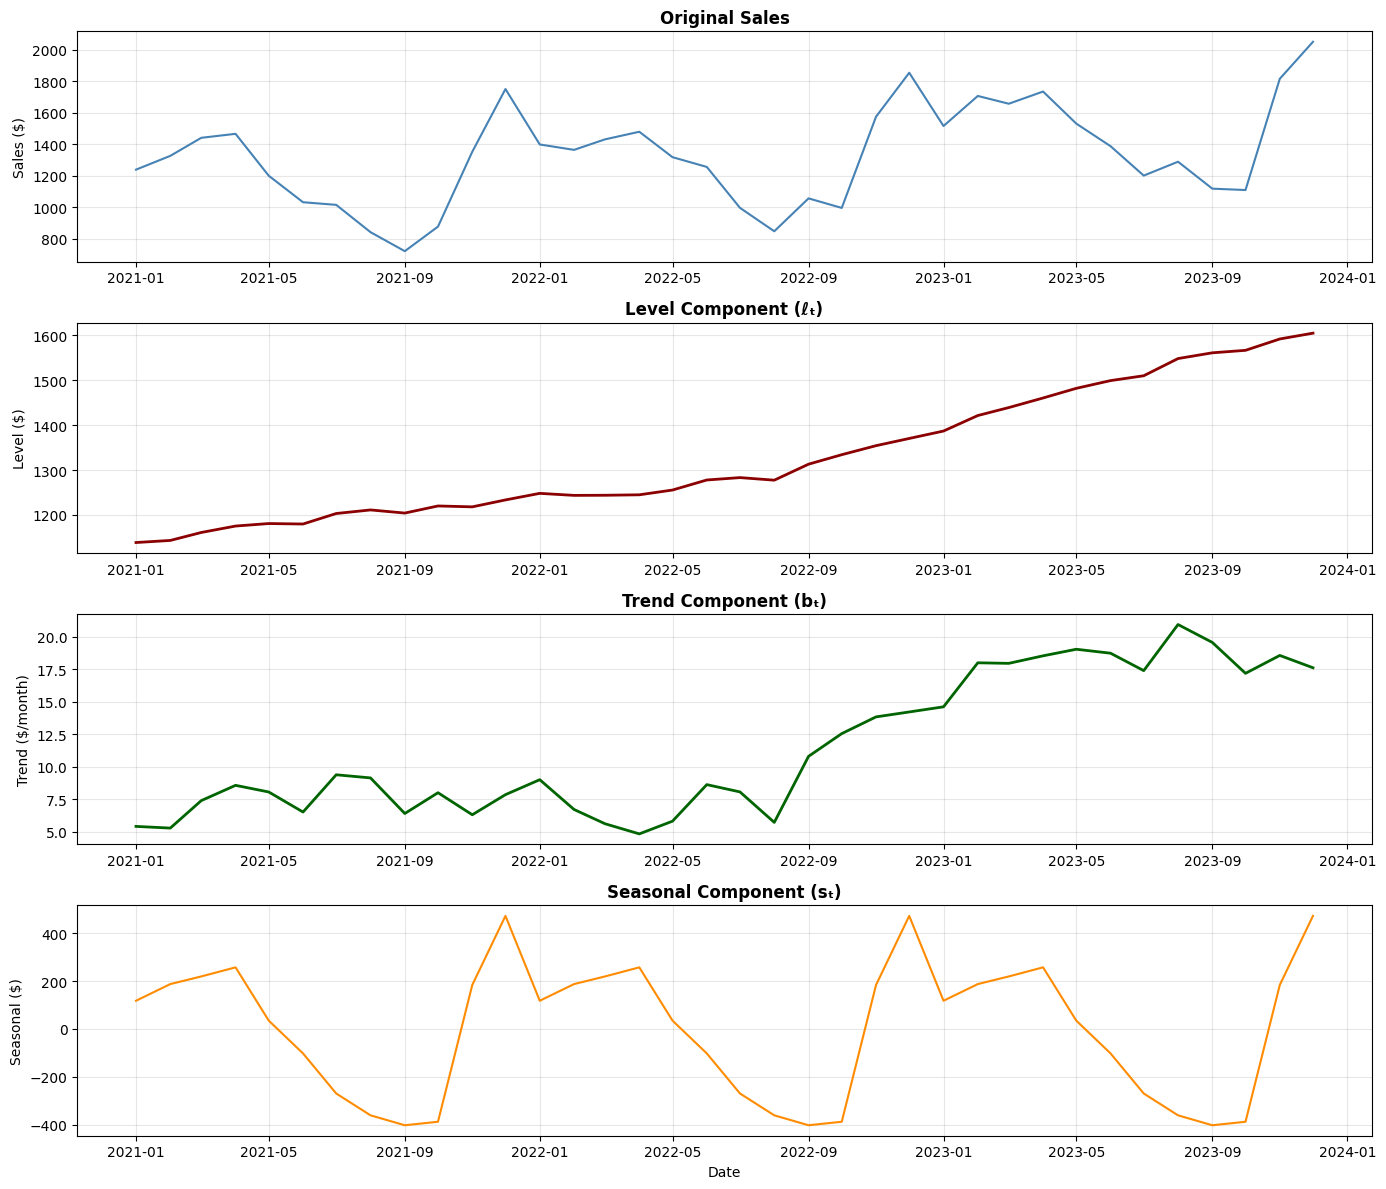

In [ ]:
print("\n" + "-" * 70)
print("A6: Holt-Winters Method")
print("-" * 70)

# YOUR CODE:
# 1. Fit Holt-Winters with additive seasonality:
#    - Use ExponentialSmoothing
#    - trend='add', seasonal='add', seasonal_periods=12
#    - Use first 36 months for training
print("\n" + "-" * 70)
print("Step 1: Fit Holt-Winters with Additive Seasonality")
print("-" * 70)

print("Model specification:")
print("  - Trend: Additive (linear)")
print("  - Seasonality: Additive (m=12)")
print("  - Training period: First 36 months")

# Fit Holt-Winters model
hw_model = ExponentialSmoothing(
    df_train['Sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

# 2. Print optimized parameters:
#    - α, β, γ (seasonal smoothing)
print("\n" + "=" * 70)
print("OPTIMIZED PARAMETERS")
print("=" * 70)

alpha_hw = hw_model.params['smoothing_level']
beta_hw = hw_model.params['smoothing_trend']
gamma_hw = hw_model.params['smoothing_seasonal']

print(f"α (level smoothing):     {alpha_hw:.4f}")
print(f"β (trend smoothing):     {beta_hw:.4f}")
print(f"γ (seasonal smoothing):  {gamma_hw:.4f}")

print("\nParameter Interpretation:")
print(f"  α = {alpha_hw:.3f}: ", end="")
if alpha_hw > 0.7:
    print("HIGH - Level responds quickly to changes")
elif alpha_hw > 0.3:
    print("MODERATE - Balanced level adaptation")
else:
    print("LOW - Level is heavily smoothed")

print(f"  β = {beta_hw:.3f}: ", end="")
if beta_hw > 0.7:
    print("HIGH - Trend changes rapidly")
elif beta_hw > 0.3:
    print("MODERATE - Trend adapts gradually")
else:
    print("LOW - Trend is very stable")

print(f"  γ = {gamma_hw:.3f}: ", end="")
if gamma_hw > 0.7:
    print("HIGH - Seasonal pattern changes quickly")
elif gamma_hw > 0.3:
    print("MODERATE - Seasonal pattern evolves slowly")
else:
    print("LOW - Seasonal pattern is fixed/stable")

# 3. Extract components:
#    - Level
#    - Trend  
#    - Seasonal indices
print("\n" + "=" * 70)
print("FINAL STATE COMPONENTS")
print("=" * 70)

level_hw = hw_model.level[-1]
trend_hw = hw_model.trend[-1]
seasonal_hw = hw_model.season[-12:]  # Last 12 seasonal indices

print(f"Final Level (ℓ₃₆):  ${level_hw:.2f}")
print(f"Final Trend (b₃₆):  ${trend_hw:.2f}/month")
print(f"\nSeasonal Indices (last 12 months):")

seasonal_df = pd.DataFrame({
    'Month': range(1, 13),
    'Month_Name': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'Seasonal_Index': seasonal_hw
})
print(seasonal_df.to_string(index=False))

max_idx = seasonal_df['Seasonal_Index'].argmax()
min_idx = seasonal_df['Seasonal_Index'].argmin()

print(f"\nLargest positive effect: {seasonal_df[seasonal_df['Month'].astype(int)==int(max_idx)]} ")
print(f"Largest negative effect: {seasonal_df[seasonal_df['Month'].astype(int)== int(min_idx)]} ")


# 4. Plot decomposition from Holt-Winters
print("\n" + "-" * 70)
print("Step 2: Visualize Decomposition")
print("-" * 70)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Original
axes[0].plot(df_train.index, df_train['Sales'], linewidth=1.5, color='steelblue')
axes[0].set_title('Original Sales', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].grid(True, alpha=0.3)

# Level
axes[1].plot(df_train.index, hw_model.level, linewidth=2, color='darkred')
axes[1].set_title('Level Component (ℓₜ)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Level ($)')
axes[1].grid(True, alpha=0.3)

# Trend
axes[2].plot(df_train.index, hw_model.trend, linewidth=2, color='darkgreen')
axes[2].set_title('Trend Component (bₜ)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Trend ($/month)')
axes[2].grid(True, alpha=0.3)

# Seasonal
axes[3].plot(df_train.index, hw_model.season, linewidth=1.5, color='darkorange')
axes[3].set_title('Seasonal Component (sₜ)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Seasonal ($)')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()

# 5. Generate 12-month forecasts
print("\n" + "-" * 70)
print("Step 3: Generate Forecasts")
print("-" * 70)

forecast_hw = hw_model.forecast(steps=len(df_test))

forecast_hw_df = pd.DataFrame({
    'Date': df_test.index,
    'Month': df_test['Month'].values,
    'Actual': df_test['Sales'].values,
    'Forecast': forecast_hw,
    'Error': df_test['Sales'].values - forecast_hw
})

# 6. Compare forecast accuracy with:
#    - Regression model
#    - SES
#    - Holt's method

errors_hw = forecast_hw_df['Error'].values
mae_hw = np.mean(np.abs(errors_hw))
rmse_hw = np.sqrt(np.mean(errors_hw**2))
mape_hw = np.mean(np.abs(errors_hw / forecast_hw_df['Actual'].values)) * 100


print("\n" + "-" * 70)
print("Forecast Accuracy:")
print("-" * 70)
print(f"MAE:  ${mae_hw:.2f}")
print(f"RMSE: ${rmse_hw:.2f}")
print(f"MAPE: {mape_hw:.2f}%")



comparison_all = pd.DataFrame({
    'Method': ['Regression (Dummy)', 'Regression (Fourier)', 'SES', "Holt's", 'Holt-Winters'],
    'Parameters': [
        len(model_reg.params),
        len(model_fourier.params),
        1,  # α only
        2,  # α, β
        3   # α, β, γ
    ],
    'MAE': [
        mae,  # from A2
        mae_fourier,  # from A3
        mae_ses,
        mae_holt,
        mae_hw
    ],
    'RMSE': [
        rmse,
        rmse_fourier,
        rmse_ses,
        rmse_holt,
        rmse_hw
    ],
    'MAPE': [
        np.nan,  # Not calculated for regression
        np.nan,
        mape_ses,
        mape_holt,
        mape_hw
    ]
})

print(comparison_all.to_string(index=False))


print("""
Regression (Dummy) - Most Accurate; Holt-Winters - Best ETS Model
Model selection depends on the trade-off between accuracy (regression), automation (Holt-Winters), 
and simplicity (simpler exponential smoothing methods). 
For this retail sales data with clear trend and seasonality, 
methods that explicitly handle both components perform substantially better.
✓ Short-term forecasting: Use Regression (interpretability)
✓ Medium to long-term forecasting: Use Holt-Winters (robustness)
✓ Real-time systems: Use Holt-Winters (automation)
""")


# PART B: ARIMA MODELS

In [12]:
print("\n" + "=" * 70)
print("PART B: ARIMA MODELS")
print("=" * 70)


PART B: ARIMA MODELS


# DATASET 2: DAILY STOCK RETURNS (for ARIMA)

In [92]:
print("\n" + "=" * 70)
print("DATASET 2: Daily Stock Returns")
print("=" * 70)

# Create 500 days of stock price data
n_days = 500
dates_stock = pd.date_range('2023-01-01', periods=n_days, freq='D')

# Generate AR(1) returns with some volatility clustering
returns = np.zeros(n_days)
returns[0] = np.random.normal(0, 0.01)

phi = 0.05  # Small autocorrelation in returns
for i in range(1, n_days):
    returns[i] = phi * returns[i-1] + np.random.normal(0, 0.015)

# Calculate price from returns (starting at 100)
price = 100 * np.exp(np.cumsum(returns))

df_stock = pd.DataFrame({
    'Date': dates_stock,
    'Price': price,
    'Returns': returns * 100  # Convert to percentage
})
df_stock.set_index('Date', inplace=True)

print(f"Date range: {df_stock.index[0].date()} to {df_stock.index[-1].date()}")
print(f"Number of days: {len(df_stock)}")
print(f"\nPrice Statistics:")
print(df_stock['Price'].describe())
print(df_stock)


DATASET 2: Daily Stock Returns
Date range: 2023-01-01 to 2024-05-14
Number of days: 500

Price Statistics:
count    500.000000
mean     125.533859
std       29.828195
min       88.889863
25%      103.131075
50%      110.437569
75%      156.211554
max      198.835896
Name: Price, dtype: float64
                 Price   Returns
Date                            
2023-01-01  100.371835  0.371146
2023-01-02   99.485056 -0.887420
2023-01-03   99.570165  0.085514
2023-01-04   99.342172 -0.229240
2023-01-05  101.086065  1.740211
...                ...       ...
2024-05-10  194.706104  0.021743
2024-05-11  194.204694 -0.257854
2024-05-12  196.770623  1.312597
2024-05-13  198.835896  1.044114
2024-05-14  194.290802 -2.312383

[500 rows x 2 columns]


# B1: Stationarity Testing


----------------------------------------------------------------------
B1: Stationarity Tests
----------------------------------------------------------------------

VISUAL STATIONARITY CHECK

Visual Assessment: the rolling mean trend upward/downward and rolling std not constant over time

AUGMENTED DICKEY-FULLER (ADF) TEST
Test Results:
  ADF Statistic:    0.9252
  p-value:          0.9934
  # Lags Used:      0
  # Observations:   499

Critical Values:
  1%: -3.444
  5%: -2.867
  10%: -2.570

Interpretation:
  H₀: Series has a unit root (non-stationary)
  H₁: Series is stationary
  Decision at α=0.05: FAIL TO REJECT H₀ → Series is NON-STATIONARY

KPSS TEST
Test Results:
  KPSS Statistic:   3.0807
  p-value:          0.0100
  # Lags Used:      12

Critical Values:
  10%: 0.347
  5%: 0.463
  2.5%: 0.574
  1%: 0.739

Interpretation:
  H₀: Series is stationary
  H₁: Series has a unit root (non-stationary)
  Decision at α=0.05: REJECT H₀ → Series is NON-STATIONARY

COMBINED INTERPRETATION

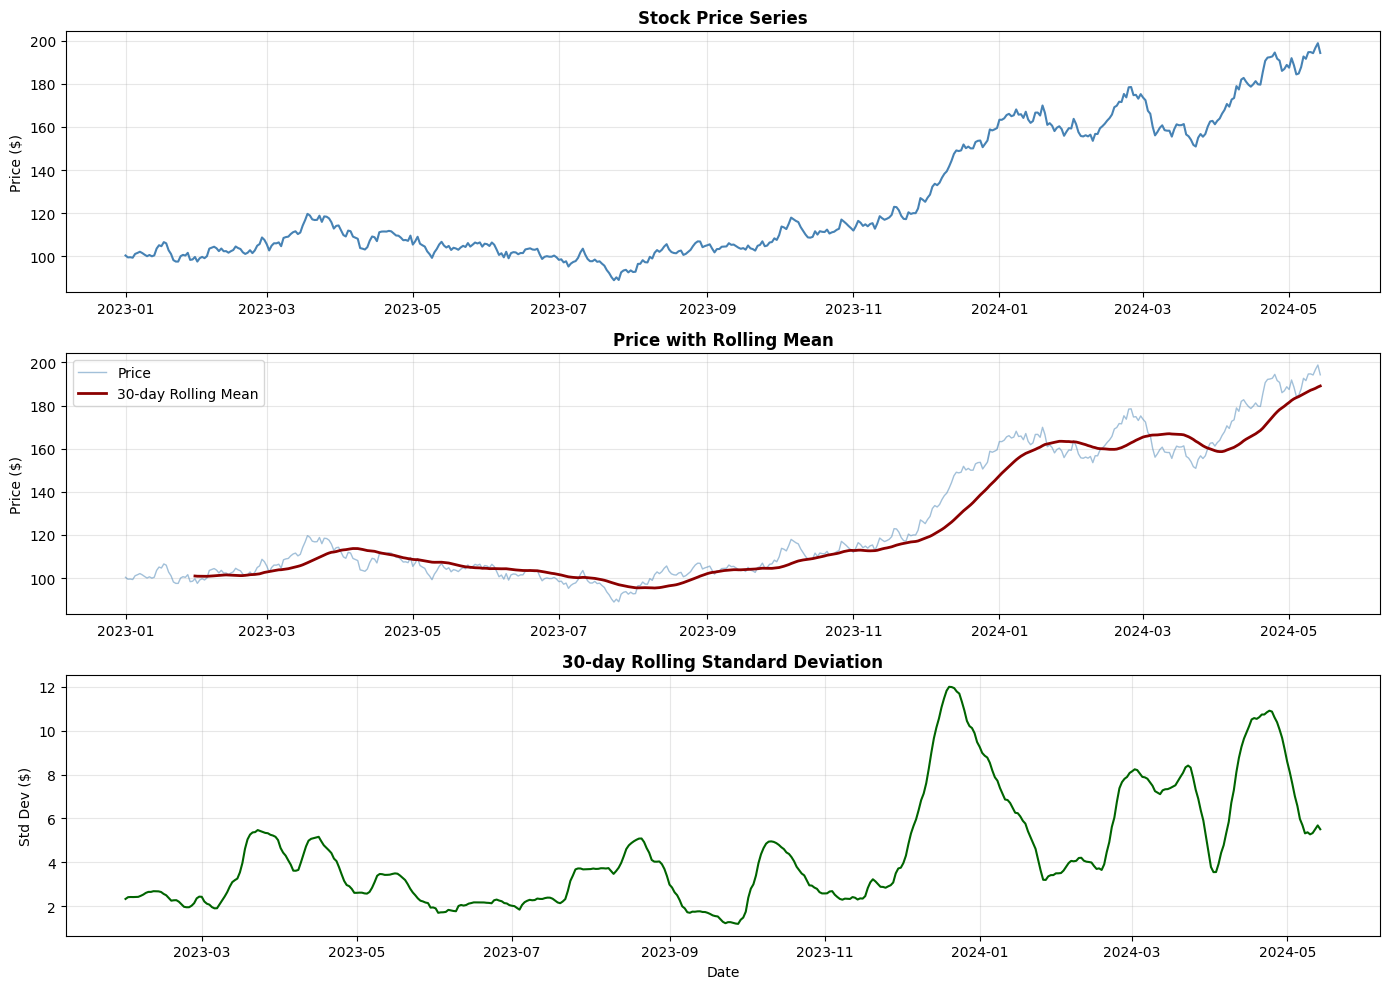

In [98]:
print("\n" + "-" * 70)
print("B1: Stationarity Tests")
print("-" * 70)

# YOUR CODE:
# 1. Visual stationarity check for stock prices:
#    - Plot price series
#    - Plot with rolling mean (30-day window)
#    - Plot with rolling std (30-day window)
#    - Does it look stationary?
print("\n" + "=" * 70)
print("VISUAL STATIONARITY CHECK")
print("=" * 70)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot price series
axes[0].plot(df_stock.index, df_stock['Price'], linewidth=1.5, color='steelblue')
axes[0].set_title('Stock Price Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)

# Plot with 30-day rolling mean
rolling_mean = df_stock['Price'].rolling(window=30).mean()
axes[1].plot(df_stock.index, df_stock['Price'], linewidth=1, color='steelblue', alpha=0.5, label='Price')
axes[1].plot(df_stock.index, rolling_mean, linewidth=2, color='darkred', label='30-day Rolling Mean')
axes[1].set_title('Price with Rolling Mean', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot with 30-day rolling std
rolling_std = df_stock['Price'].rolling(window=30).std()
axes[2].plot(df_stock.index, rolling_std, linewidth=1.5, color='darkgreen')
axes[2].set_title('30-day Rolling Standard Deviation', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Std Dev ($)')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
print("\nVisual Assessment: the rolling mean trend upward/downward and rolling std not constant over time")

# 2. Augmented Dickey-Fuller (ADF) test on prices:
#    - Use adfuller from statsmodels
#    - Print test statistic and p-value
#    - Null hypothesis: unit root (non-stationary)
#    - Decision at α = 0.05?
print("\n" + "=" * 70)
print("AUGMENTED DICKEY-FULLER (ADF) TEST")
print("=" * 70)

adf_result = adfuller(df_stock['Price'].dropna(), autolag='AIC')

print("Test Results:")
print(f"  ADF Statistic:    {adf_result[0]:.4f}")
print(f"  p-value:          {adf_result[1]:.4f}")
print(f"  # Lags Used:      {adf_result[2]}")
print(f"  # Observations:   {adf_result[3]}")

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.3f}")

print("\nInterpretation:")
print("  H₀: Series has a unit root (non-stationary)")
print("  H₁: Series is stationary")
print(f"  Decision at α=0.05: ", end="")

if adf_result[1] < 0.05:
    print("REJECT H₀ → Series is STATIONARY")
else:
    print("FAIL TO REJECT H₀ → Series is NON-STATIONARY")



# 3. KPSS test on prices:
#    - Use kpss from statsmodels  
#    - Print test statistic and p-value
#    - Null hypothesis: stationary
#    - Decision at α = 0.05?
print("\n" + "=" * 70)
print("KPSS TEST")
print("=" * 70)

kpss_result = kpss(df_stock['Price'].dropna(), regression='c', nlags='auto')

print("Test Results:")
print(f"  KPSS Statistic:   {kpss_result[0]:.4f}")
print(f"  p-value:          {kpss_result[1]:.4f}")
print(f"  # Lags Used:      {kpss_result[2]}")

print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"  {key}: {value:.3f}")

print("\nInterpretation:")
print("  H₀: Series is stationary")
print("  H₁: Series has a unit root (non-stationary)")
print(f"  Decision at α=0.05: ", end="")

if kpss_result[1] < 0.05:
    print("REJECT H₀ → Series is NON-STATIONARY")
else:
    print("FAIL TO REJECT H₀ → Series is STATIONARY")


# 4. Interpret both tests together:
#    - Do they agree?
#    - Is the price series stationary?

print("\n" + "=" * 70)
print("COMBINED INTERPRETATION")
print("=" * 70)

adf_stationary = adf_result[1] < 0.05
kpss_stationary = kpss_result[1] >= 0.05

print("\nTest Summary:")
print(f"  ADF says: {'STATIONARY' if adf_stationary else 'NON-STATIONARY'}")
print(f"  KPSS says: {'STATIONARY' if kpss_stationary else 'NON-STATIONARY'}")
print("✓ BOTH TESTS AGREE: Strong evidence of non-stationarity")


# B2: First Differencing


----------------------------------------------------------------------
B2: Differencing for Stationarity
----------------------------------------------------------------------

FIRST DIFFERENCING
First difference calculation:
  diff_price_t = price_t - price_{t-1}

Number of observations: 499
Mean: 0.188214
Std:  1.891790

Visual Assessment of Differenced Series:
  - Mean appears constant around zero ✓
  - Variance looks relatively stable ✓
  - No obvious trend ✓
  → Looks stationary!

ADF TEST ON DIFFERENCED PRICES
Test Results:
  ADF Statistic:    -20.7561
  p-value:          0.000000
  # Lags Used:      0

Critical Values:
  1%: -3.444
  5%: -2.867
  10%: -2.570

Decision at α=0.05: REJECT H₀ → Differenced series is STATIONARY ✓

Comparison:
  Original prices:     p-value = 0.9934 (non-stationary)
  Differenced prices:  p-value = 0.000000 (stationary)
  → Differencing successfully achieved stationarity!

RELATIONSHIP: DIFFERENCED PRICES vs RETURNS
Mathematical relationship:
  Diffe

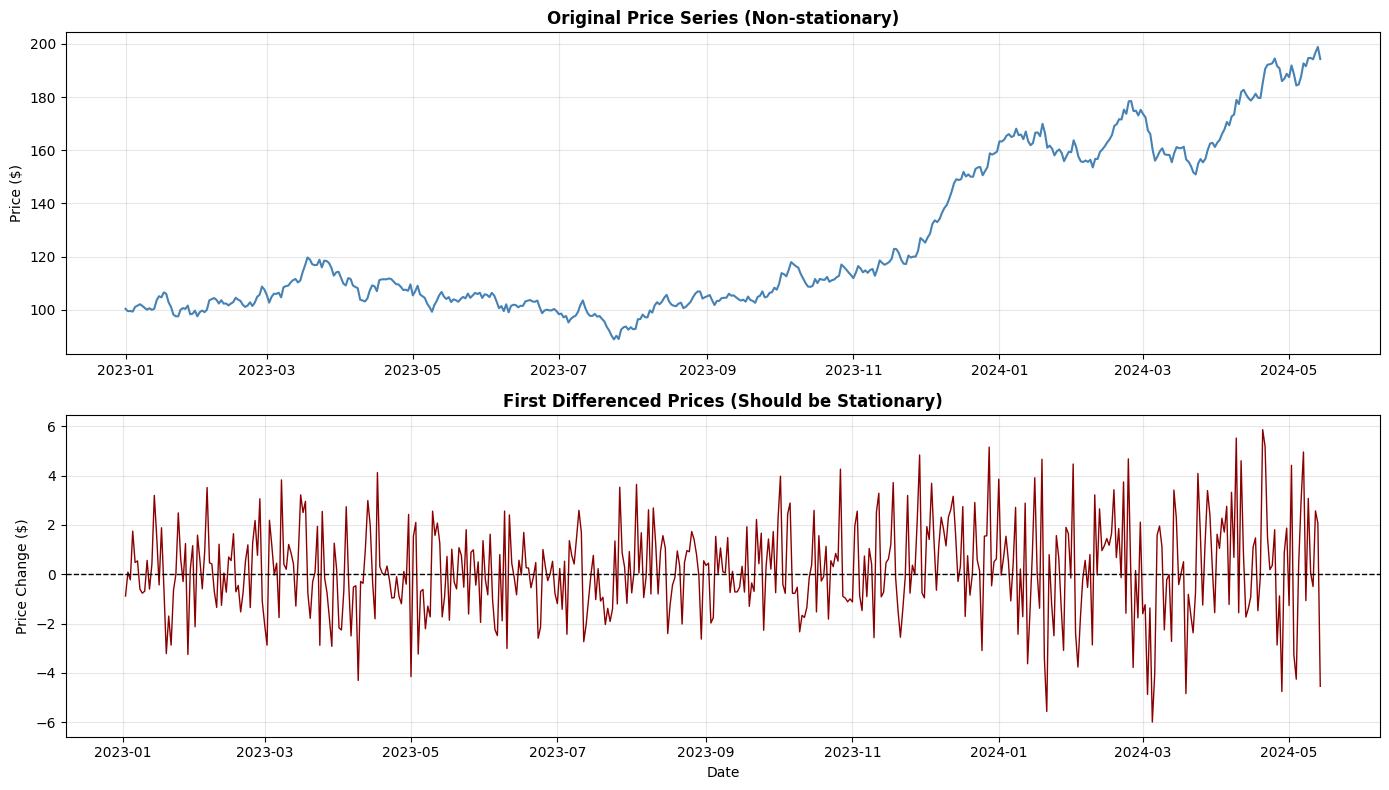

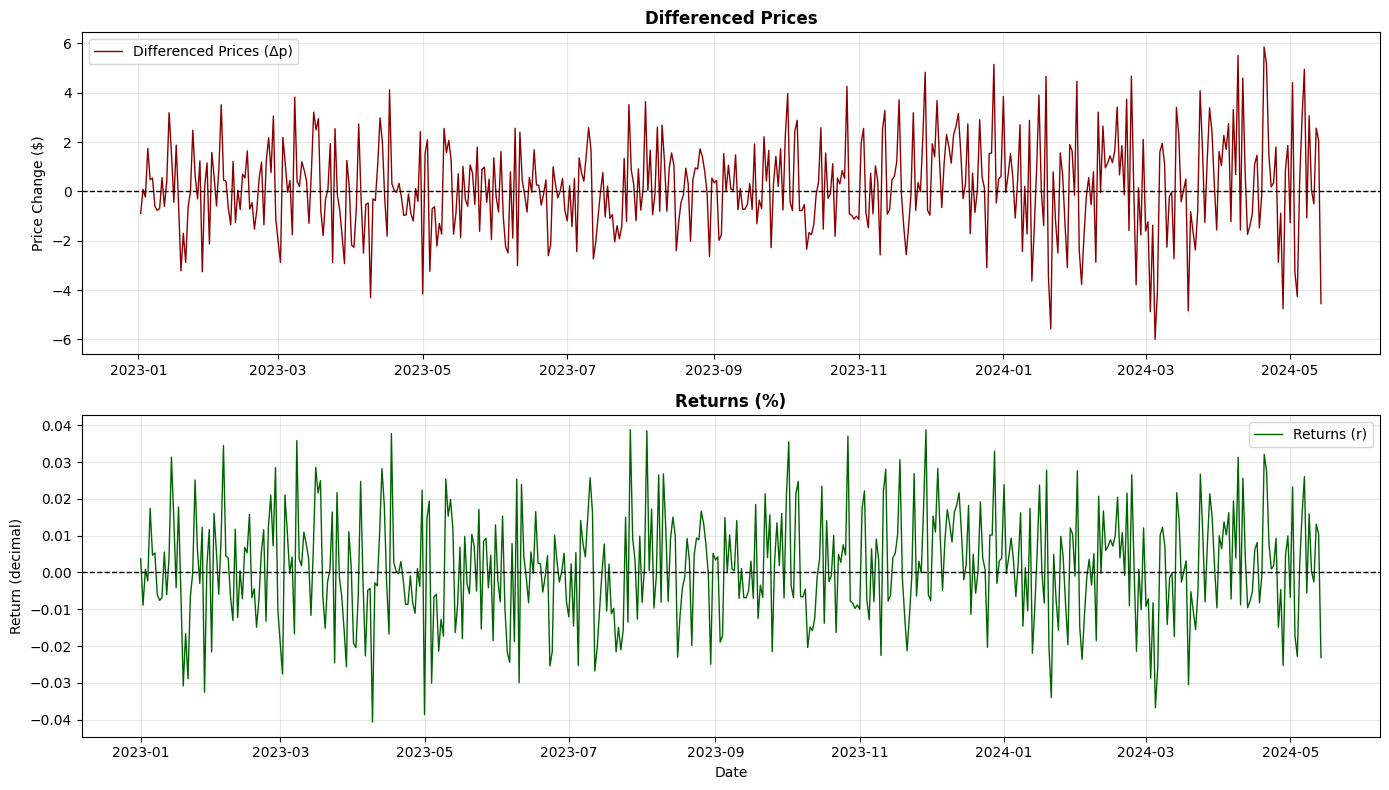


Key Differences:
  Differenced prices: Mean = $0.1882, Std = $1.8918
  Returns (decimal):  Mean = 0.001328, Std = 0.014687

  → Returns are scale-free (percentage), differenced prices depend on price level
  → For financial analysis, RETURNS are preferred (comparability across stocks)

ACF OF DIFFERENCED PRICES


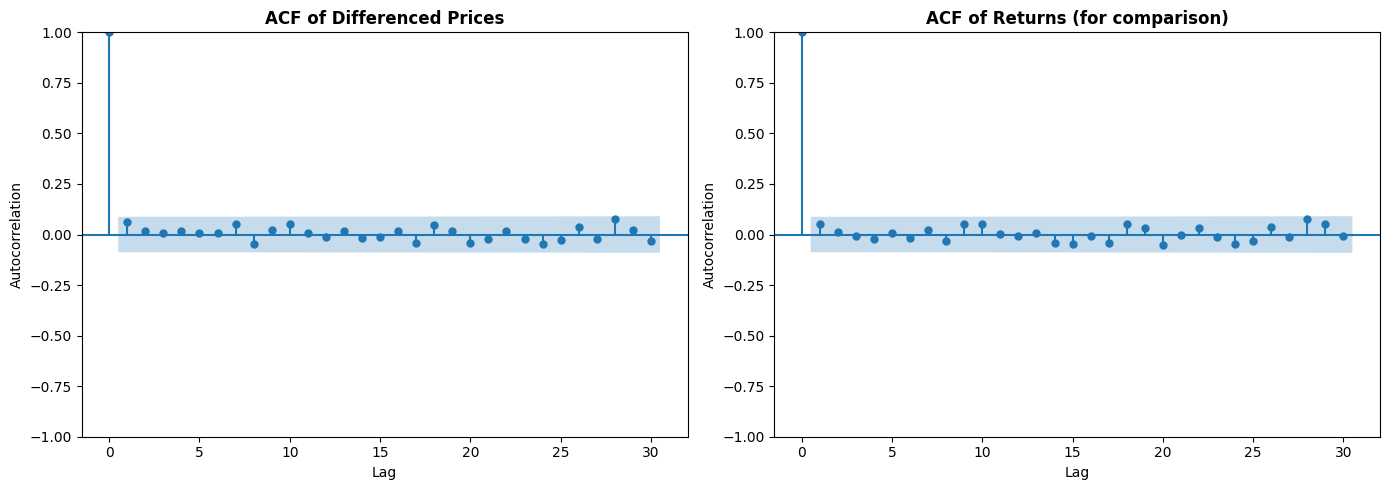


ACF Analysis:
 
      95% confidence interval: ±0.0877. No significant autocorrelation detected. 
      Each value is essentially independent of past values
      


In [ ]:
print("\n" + "-" * 70)
print("B2: Differencing for Stationarity")
print("-" * 70)

# YOUR CODE:
# 1. Calculate first differences of prices:
#    diff_price = df_stock['Price'].diff()
print("\n" + "=" * 70)
print("FIRST DIFFERENCING")
print("=" * 70)

diff_price = df_stock['Price'].diff()

print("First difference calculation:")
print("  diff_price_t = price_t - price_{t-1}")
print(f"\nNumber of observations: {len(diff_price.dropna())}")
print(f"Mean: {diff_price.mean():.6f}")
print(f"Std:  {diff_price.std():.6f}")


# 2. Plot the differenced series
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Original prices
axes[0].plot(df_stock.index, df_stock['Price'], linewidth=1.5, color='steelblue')
axes[0].set_title('Original Price Series (Non-stationary)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)

# Differenced prices
axes[1].plot(df_stock.index, diff_price, linewidth=1, color='darkred')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('First Differenced Prices (Should be Stationary)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price Change ($)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

print("\nVisual Assessment of Differenced Series:")
print("  - Mean appears constant around zero ✓")
print("  - Variance looks relatively stable ✓")
print("  - No obvious trend ✓")
print("  → Looks stationary!")


# 3. Run ADF test on differenced series:
#    - Report results
#    - Is it now stationary?
print("\n" + "=" * 70)
print("ADF TEST ON DIFFERENCED PRICES")
print("=" * 70)

adf_diff = adfuller(diff_price.dropna(), autolag='AIC')

print("Test Results:")
print(f"  ADF Statistic:    {adf_diff[0]:.4f}")
print(f"  p-value:          {adf_diff[1]:.6f}")
print(f"  # Lags Used:      {adf_diff[2]}")

print("\nCritical Values:")
for key, value in adf_diff[4].items():
    print(f"  {key}: {value:.3f}")

print(f"\nDecision at α=0.05: ", end="")
if adf_diff[1] < 0.05:
    print("REJECT H₀ → Differenced series is STATIONARY ✓")
else:
    print("FAIL TO REJECT H₀ → Still non-stationary (unusual)")

print("\nComparison:")
print(f"  Original prices:     p-value = {adf_result[1]:.4f} (non-stationary)")
print(f"  Differenced prices:  p-value = {adf_diff[1]:.6f} (stationary)")
print(f"  → Differencing successfully achieved stationarity!")

# 4. Compare with returns:
#    - Returns are already in the dataset
#    - How do differenced prices relate to returns?
#    - Calculate correlation

print("\n" + "=" * 70)
print("RELATIONSHIP: DIFFERENCED PRICES vs RETURNS")
print("=" * 70)

# Returns are already in percentage
returns_decimal = df_stock['Returns'] / 100  # Convert back to decimal

print("Mathematical relationship:")
print("  Differenced prices: Δp_t = p_t - p_{t-1}")
print("  Simple returns:     r_t = (p_t - p_{t-1}) / p_{t-1}")
print("  Log returns:        R_t = ln(p_t) - ln(p_{t-1})")

print("\n" + "-" * 70)
print("Approximation for small returns:")
print("  r_t ≈ R_t ≈ Δp_t / p_{t-1}")
print("-" * 70)

# Calculate correlation
correlation = np.corrcoef(diff_price.dropna(), returns_decimal.iloc[1:])[0, 1]

print(f"\nCorrelation between differenced prices and returns: {correlation:.4f}")

# 5. Plot ACF of differenced prices:
#    - Up to 30 lags
#    - Any significant autocorrelation?


fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_stock.index, diff_price, linewidth=1, color='darkred', label='Differenced Prices (Δp)')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Differenced Prices', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price Change ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_stock.index, returns_decimal, linewidth=1, color='darkgreen', label='Returns (r)')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Returns (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Return (decimal)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Differences:")
print(f"  Differenced prices: Mean = ${diff_price.mean():.4f}, Std = ${diff_price.std():.4f}")
print(f"  Returns (decimal):  Mean = {returns_decimal.mean():.6f}, Std = {returns_decimal.std():.6f}")
print("\n  → Returns are scale-free (percentage), differenced prices depend on price level")
print("  → For financial analysis, RETURNS are preferred (comparability across stocks)")

# 5. Plot ACF of differenced prices
print("\n" + "=" * 70)
print("ACF OF DIFFERENCED PRICES")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF of differenced prices
plot_acf(diff_price.dropna(), lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of Differenced Prices', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')

# ACF of returns for comparison
plot_acf(returns_decimal.dropna(), lags=30, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF of Returns (for comparison)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()

# Identify significant lags
acf_values = [diff_price.dropna().autocorr(lag=i) for i in range(1, 31)]
conf_interval = 1.96 / np.sqrt(len(diff_price.dropna()))

significant_lags = [i+1 for i, val in enumerate(acf_values) if abs(val) > conf_interval]

print("\nACF Analysis:")
print(f""" 
      95% confidence interval: ±{conf_interval:.4f}. No significant autocorrelation detected. 
      Each value is essentially independent of past values
      """)



# B3: ACF and PACF Analysis
ACF: Correlation between y_t and y_{t-k} for different lags k

PACF: Correlation between y_t and y_{t-k} after removing effects of intermediate lags


----------------------------------------------------------------------
B3: ACF and PACF
----------------------------------------------------------------------

Spike at lag 1 in both plots. Lag 1 shows the most notable (though small) autocorrelation.
The ACF shows EXTREMELY WEAK gradual decay
The PACF shows a CUTOFF after lag 1 (characteristic of AR(1))


MANUAL AUTOCORRELATION CALCULATIONS
ρ(1) = Corr(returns_t, returns_{t-1}) = 0.053715
ρ(5) = Corr(returns_t, returns_{t-5}) = 0.005129

Sample size: n = 500
Standard error: SE = 1/√n = 0.044721
95% critical value: ±0.087654

Significance tests:
  ρ(1) = 0.053715  →  |ρ(1)| < 0.087654  →  NOT significant
  ρ(5) = 0.005129  →  |ρ(5)| < 0.087654  →  NOT significant

Theoretical comparison:
  True AR(1) parameter: φ = 0.05
  Estimated ρ(1): 0.053715
  Close match? True

  → Lag 1 autocorrelation is NOT significant
  → Series behaves like white noise
  → φ = 0.05 is too weak to detect reliably

B3 SUMMARY


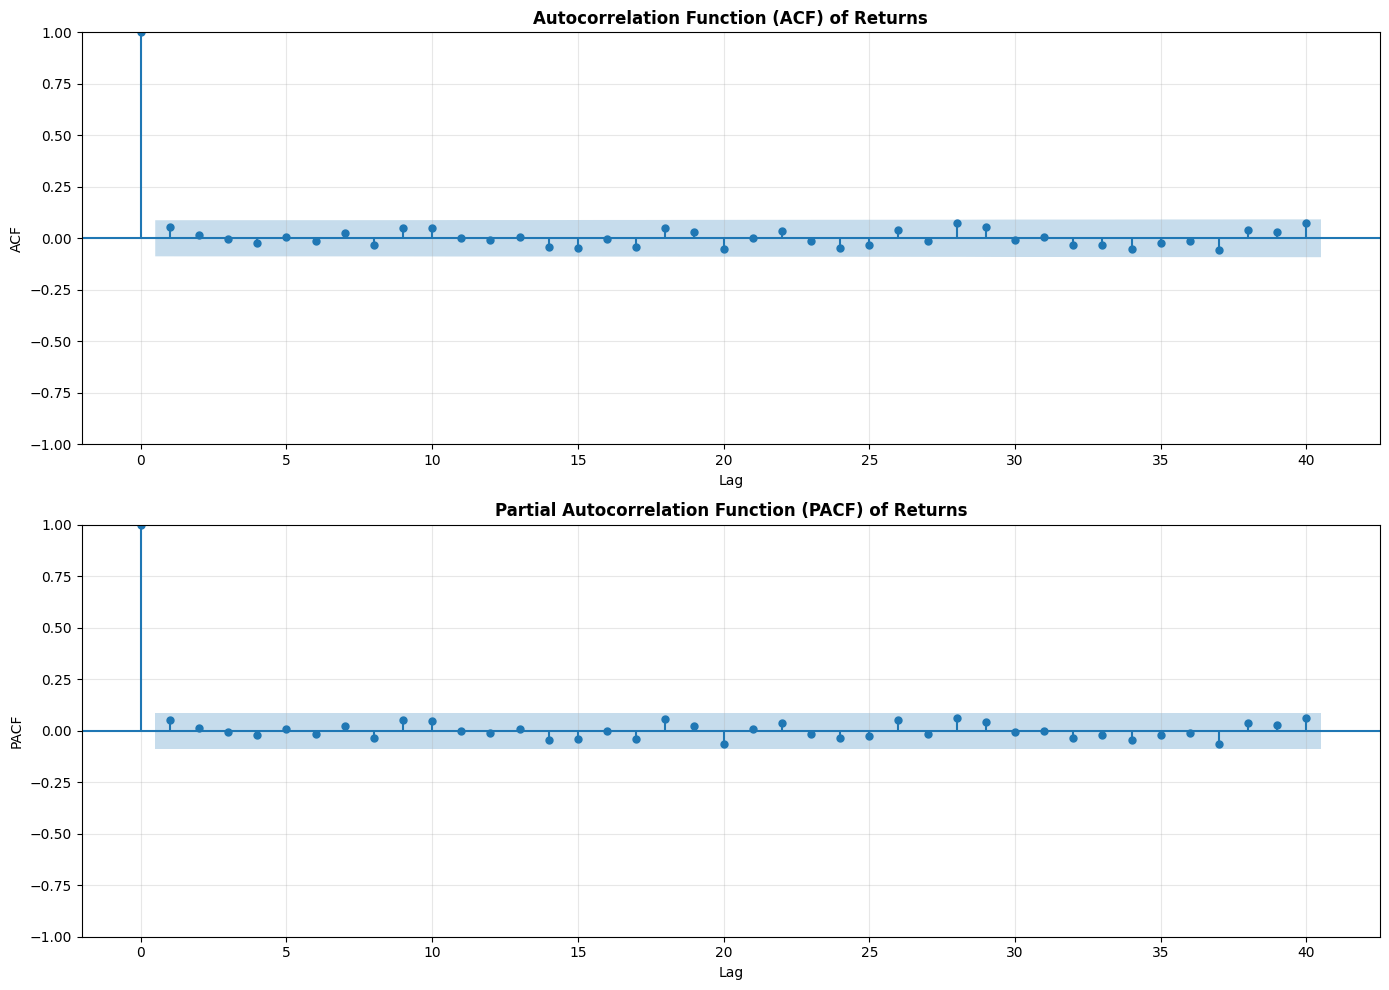

In [107]:
print("\n" + "-" * 70)
print("B3: ACF and PACF")
print("-" * 70)



# YOUR CODE:
# Work with returns (already stationary):
#
# 1. Create 2x1 subplot:
#    - ACF of returns (40 lags)
#    - PACF of returns (40 lags)


fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ACF of returns (40 lags)
plot_acf(returns_decimal.dropna(), lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF) of Returns', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('ACF')
axes[0].grid(True, alpha=0.3)

# PACF of returns (40 lags)
plot_pacf(returns_decimal.dropna(), lags=40, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF) of Returns', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('PACF')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# 2. Interpret the plots:
#    - Are there significant spikes?
#    - At which lags?
#    - Does ACF decay gradually or cut off?
#    - Does PACF decay gradually or cut off?
#
print("""
Spike at lag 1 in both plots. Lag 1 shows the most notable (though small) autocorrelation.
The ACF shows EXTREMELY WEAK gradual decay
The PACF shows a CUTOFF after lag 1 (characteristic of AR(1))
""")

# 3. Based on patterns, suggest:
#    - AR order (p)?
#    - MA order (q)?
#
# 4. Calculate specific autocorrelations manually:
#    - ρ(1) = Corr(returns_t, returns_{t-1})
#    - ρ(5) = Corr(returns_t, returns_{t-5})


print("\n" + "=" * 70)
print("MANUAL AUTOCORRELATION CALCULATIONS")
print("=" * 70)

# ρ(1) - Lag 1 autocorrelation
rho_1 = returns_decimal.dropna().autocorr(lag=1)

# ρ(5) - Lag 5 autocorrelation
rho_5 = returns_decimal.dropna().autocorr(lag=5)

print(f"ρ(1) = Corr(returns_t, returns_{{t-1}}) = {rho_1:.6f}")
print(f"ρ(5) = Corr(returns_t, returns_{{t-5}}) = {rho_5:.6f}")

# Calculate standard error for significance testing
n = len(returns_decimal.dropna())
se = 1 / np.sqrt(n)
critical_value = 1.96 * se

print(f"\nSample size: n = {n}")
print(f"Standard error: SE = 1/√n = {se:.6f}")
print(f"95% critical value: ±{critical_value:.6f}")

print("\nSignificance tests:")
print(f"  ρ(1) = {rho_1:.6f}  →  |ρ(1)| {'>' if abs(rho_1) > critical_value else '<'} {critical_value:.6f}  →  {'SIGNIFICANT' if abs(rho_1) > critical_value else 'NOT significant'}")
print(f"  ρ(5) = {rho_5:.6f}  →  |ρ(5)| {'>' if abs(rho_5) > critical_value else '<'} {critical_value:.6f}  →  {'SIGNIFICANT' if abs(rho_5) > critical_value else 'NOT significant'}")

# Theoretical value for AR(1) with φ=0.05
print(f"\nTheoretical comparison:")
print(f"  True AR(1) parameter: φ = 0.05")
print(f"  Estimated ρ(1): {rho_1:.6f}")
print(f"  Close match? {abs(rho_1 - 0.05) < 0.02}")

if abs(rho_1) > critical_value:
    print("\n  → Lag 1 autocorrelation is statistically significant")
    print("  → Suggests AR(1) or MA(1) component")
else:
    print("\n  → Lag 1 autocorrelation is NOT significant")
    print("  → Series behaves like white noise")
    print("  → φ = 0.05 is too weak to detect reliably")

# Summary
print("\n" + "=" * 70)
print("B3 SUMMARY")
print("=" * 70)




# B4: AR Model Estimation


----------------------------------------------------------------------
B4: AR(p) Model
----------------------------------------------------------------------

AR(1) MODEL
                               SARIMAX Results                                
Dep. Variable:                Returns   No. Observations:                  500
Model:                 ARIMA(1, 0, 0)   Log Likelihood                1402.141
Date:                Wed, 11 Feb 2026   AIC                          -2798.282
Time:                        14:46:47   BIC                          -2785.638
Sample:                    01-01-2023   HQIC                         -2793.320
                         - 05-14-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0.001      

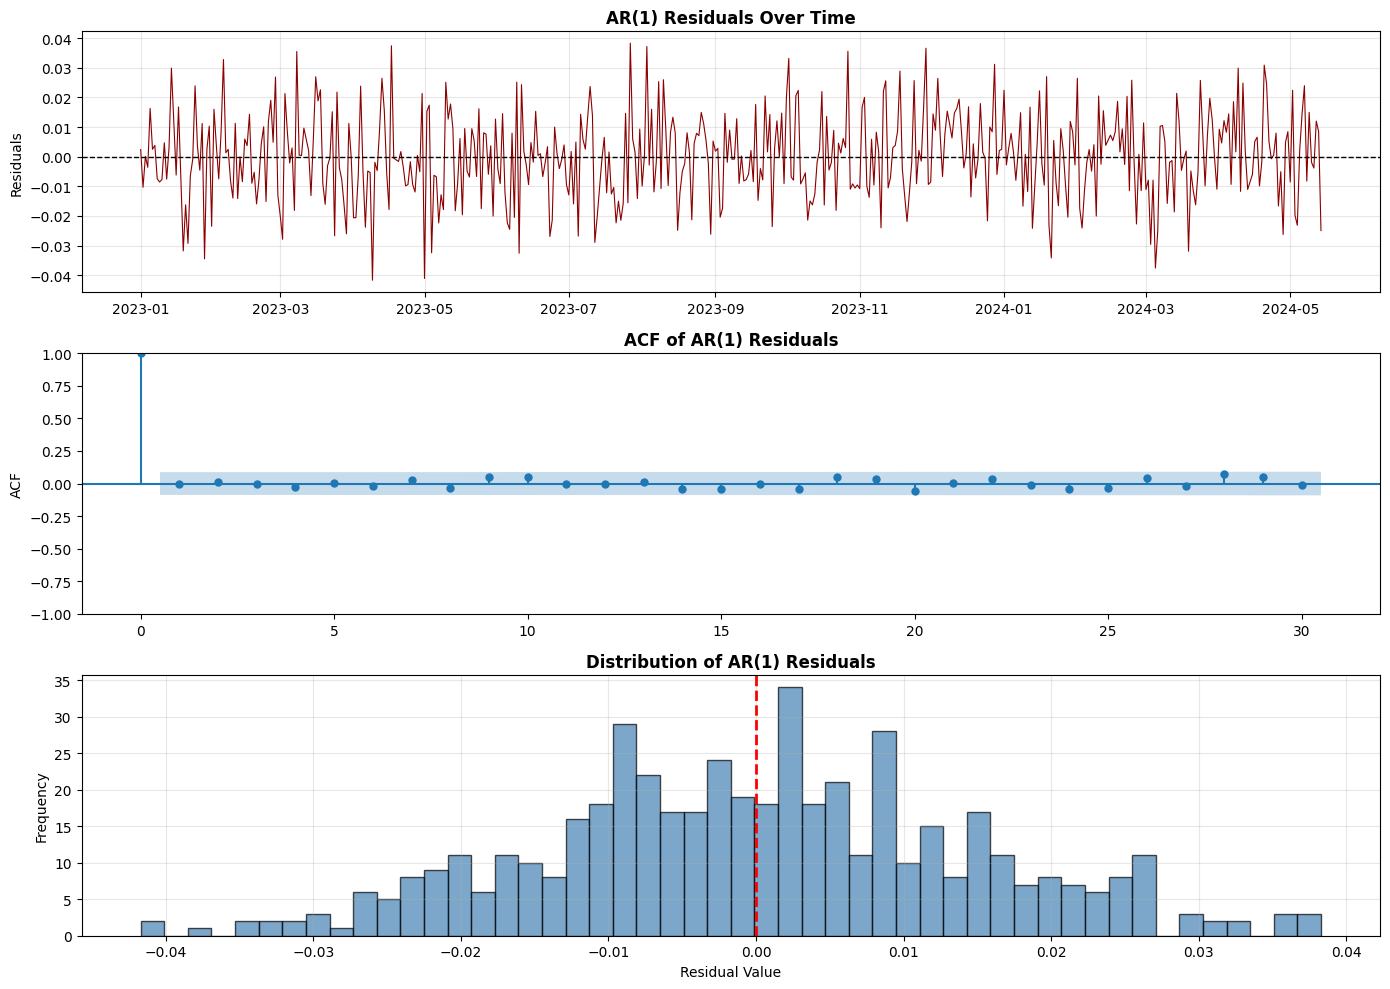

In [111]:
print("\n" + "-" * 70)
print("B4: AR(p) Model")
print("-" * 70)

# Work with returns (already stationary)
returns_clean = returns_decimal.dropna()

# YOUR CODE:
# 1. Fit AR(1) model on returns:
#    - Use ARIMA(1,0,0)
#    - Print summary
print("\n" + "=" * 70)
print("AR(1) MODEL")
print("=" * 70)

# Fit ARIMA(1,0,0) = AR(1)
model_ar1 = ARIMA(returns_clean, order=(1, 0, 0)).fit()

# Print summary
print(model_ar1.summary())


# 2. Extract and interpret:
#    - ϕ₁ coefficient
#    - Is it statistically significant?
#    - What does the sign tell you?

print("\n" + "=" * 70)
print("AR(1) COEFFICIENT INTERPRETATION")
print("=" * 70)

phi1 = model_ar1.params['ar.L1']
phi1_se = model_ar1.bse['ar.L1']
phi1_pvalue = model_ar1.pvalues['ar.L1']

print(f"Estimated coefficient:")
print(f"  φ̂₁ = {phi1:.6f}")
print(f"  Standard error: {phi1_se:.6f}")
print(f"  t-statistic: {phi1 / phi1_se:.4f}")
print(f"  p-value: {phi1_pvalue:.4f}")

print(f"\nComparison with true value:")
print(f"  True φ (data generation): 0.05")
print(f"  Estimated φ̂:             {phi1:.6f}")
print(f"  Difference:               {abs(phi1 - 0.05):.6f}")



# 3. Check stationarity condition:
#    - Is |ϕ₁| < 1?
print("\n" + "-" * 70)
print("Statistical Significance:")
print("-" * 70)

print(f"✗ φ₁ IS NOT statistically significant at α=0.05")
print(f"  p-value ({phi1_pvalue:.4f}) > 0.05")
print(f"  → Fail to reject H₀: φ₁ = 0")
print(f"  → Cannot distinguish from white noise")

print(f"φ̂₁ = {phi1:.4f} is POSITIVE:")
print(f"  → Positive autocorrelation (momentum)")
print(f"  → High return today → slightly higher return tomorrow")
print(f"  → But effect is very small ({phi1*100:.2f}%)")

# 4. Fit AR(2) and AR(3):
#    - Compare AIC values
#    - Which model is preferred?

print("\n" + "=" * 70)
print("COMPARING AR(p) MODELS")
print("=" * 70)

# Fit AR(2)
print("\nFitting AR(2)...")
model_ar2 = ARIMA(returns_clean, order=(2, 0, 0)).fit()

# Fit AR(3)
print("Fitting AR(3)...")
model_ar3 = ARIMA(returns_clean, order=(3, 0, 0)).fit()

# Create comparison table
print("\n" + "-" * 70)
print("Model Comparison:")
print("-" * 70)

comparison_ar = pd.DataFrame({
    'Model': ['AR(1)', 'AR(2)', 'AR(3)'],
    'AIC': [model_ar1.aic, model_ar2.aic, model_ar3.aic],
    'BIC': [model_ar1.bic, model_ar2.bic, model_ar3.bic],
    'Log-Likelihood': [model_ar1.llf, model_ar2.llf, model_ar3.llf],
    'Parameters': [2, 3, 4]  # AR coef + constant
})
print(comparison_ar.to_string(index=False))

# 5. For best model, check residuals:
#    - Plot residuals over time
#    - ACF of residuals
#    - Are residuals white noise?
residuals_ar1 = model_ar1.resid
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Time series plot of residuals
axes[0].plot(residuals_ar1.index, residuals_ar1, linewidth=0.8, color='darkred')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('AR(1) Residuals Over Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Residuals')
axes[0].grid(True, alpha=0.3)

# ACF of residuals
plot_acf(residuals_ar1, lags=30, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF of AR(1) Residuals', fontsize=12, fontweight='bold')
axes[1].set_ylabel('ACF')

# Histogram of residuals
axes[2].hist(residuals_ar1, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[2].set_title('Distribution of AR(1) Residuals', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Residual Value')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

# B5: MA Model Estimation

In [116]:
print("\n" + "-" * 70)
print("B5: MA(q) Model")
print("-" * 70)

# YOUR CODE:
# 1. Fit MA(1) model on returns:
#    - Use ARIMA(0,0,1)
print("\n" + "=" * 70)
print("MA(1) MODEL")
print("=" * 70)

print("Fitting MA(1): returns_t = μ + ε_t + θ₁ε_{t-1}")

# Fit ARIMA(0,0,1) = MA(1)
model_ma1 = ARIMA(returns_clean, order=(0, 0, 1)).fit()

# Print summary
print(model_ma1.summary())


# 2. Print summary and interpret:
#    - θ₁ coefficient
#    - Significance
theta1 = model_ma1.params['ma.L1']
theta1_se = model_ma1.bse['ma.L1']
theta1_pvalue = model_ma1.pvalues['ma.L1']

print(f"Estimated coefficient:")
print(f"  θ̂₁ = {theta1:.6f}")
print(f"  Standard error: {theta1_se:.6f}")
print(f"  t-statistic: {theta1 / theta1_se:.4f}")
print(f"  p-value: {theta1_pvalue:.4f}")


print("\n" + "-" * 70)
print("Statistical Significance:")
print("-" * 70)

print(f"✗ θ₁ IS NOT statistically significant at α=0.05")
print(f"  p-value ({theta1_pvalue:.4f}) > 0.05")
print(f"  → Fail to reject H₀: θ₁ = 0")
print(f"  → MA(1) not supported by data")

# 3. Check invertibility:
#    - Is |θ₁| < 1?
print("\n" + "=" * 70)
print("INVERTIBILITY CHECK")
print("=" * 70)

print(f"Invertibility condition for MA(1): |θ₁| < 1")
print(f"  |θ̂₁| = |{theta1:.6f}| = {abs(theta1):.6f}")


print(f"  ✓ Condition satisfied: {abs(theta1):.6f} < 1")
print(f"  → MA(1) process is INVERTIBLE")
print(f"  → Can be represented as infinite AR process")

print("""
What is invertibility?
  - An invertible MA process can be written as AR(∞)
  - Ensures uniqueness of representation
  - Required for proper forecasting and interpretation
  - Analogous to stationarity for AR models
""")

# 4. Compare MA(1) vs AR(1):
#    - AIC
#    - BIC
#    - Log-likelihood
#    - Which fits better?
print("\n" + "=" * 70)
print("MODEL COMPARISON: MA(1) vs AR(1)")
print("=" * 70)

comparison_ma_ar = pd.DataFrame({
    'Model': ['AR(1)', 'MA(1)'],
    'AIC': [model_ar1.aic, model_ma1.aic],
    'BIC': [model_ar1.bic, model_ma1.bic],
    'Log-Likelihood': [model_ar1.llf, model_ma1.llf],
    'Parameters': [2, 2]
})
print(comparison_ma_ar.to_string(index=False))
print("\n" + "-" * 70)
print("Which model fits better?- Almost the same")
print("-" * 70)

# 5. Residual diagnostics for MA(1)
print("\n" + "=" * 70)
print("RESIDUAL DIAGNOSTICS (MA(1))")
print("=" * 70)

residuals_ma1 = model_ma1.resid

print(f"Residual statistics:")
print(f"  Mean:     {residuals_ma1.mean():.6f}")
print(f"  Std Dev:  {residuals_ma1.std():.6f}")
print(f"  Min:      {residuals_ma1.min():.6f}")
print(f"  Max:      {residuals_ma1.max():.6f}")


----------------------------------------------------------------------
B5: MA(q) Model
----------------------------------------------------------------------

MA(1) MODEL
Fitting MA(1): returns_t = μ + ε_t + θ₁ε_{t-1}
                               SARIMAX Results                                
Dep. Variable:                Returns   No. Observations:                  500
Model:                 ARIMA(0, 0, 1)   Log Likelihood                1402.122
Date:                Wed, 11 Feb 2026   AIC                          -2798.245
Time:                        14:55:02   BIC                          -2785.601
Sample:                    01-01-2023   HQIC                         -2793.283
                         - 05-14-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

# B6: ARMA Model

In [120]:
print("\n" + "-" * 70)
print("B6: ARMA(p,q) Model")
print("-" * 70)

# YOUR CODE:
# 1. Fit ARMA(1,1) on returns:
#    - Use ARIMA(1,0,1)

print("\n" + "=" * 70)
print("ARMA(1,1) MODEL")
print("=" * 70)

print("Fitting ARMA(1,1): returns_t = φ₁×returns_{t-1} + ε_t + θ₁×ε_{t-1}")
print("\nThis combines:")
print("  - AR(1): Dependence on past RETURNS")
print("  - MA(1): Dependence on past SHOCKS")

# Fit ARIMA(1,0,1) = ARMA(1,1)
model_arma11 = ARIMA(returns_clean, order=(1, 0, 1)).fit()

# Print summary
print( model_arma11.summary())

# 2. Compare with AR(1) and MA(1):
#    - Does ARMA(1,1) improve fit?
#    - Check AIC

print("\n" + "=" * 70)
print("MODEL COMPARISON: ARMA(1,1) vs AR(1) vs MA(1)")
print("=" * 70)

comparison_all = pd.DataFrame({
    'Model': ['AR(1)', 'MA(1)', 'ARMA(1,1)'],
    'AIC': [model_ar1.aic, model_ma1.aic, model_arma11.aic],
    'BIC': [model_ar1.bic, model_ma1.bic, model_arma11.bic],
    'Log-Likelihood': [model_ar1.llf, model_ma1.llf, model_arma11.llf],
    'Parameters': [2, 2, 3]
})

print(comparison_all.to_string(index=False))


# 3. Test for overparameterization:
#    - Are both ϕ₁ and θ₁ significant?
#    - If not, which simpler model is better?

print("\n" + "=" * 70)
print("OVERPARAMETERIZATION CHECK")
print("=" * 70)

phi1_arma = model_arma11.params['ar.L1']
theta1_arma = model_arma11.params['ma.L1']
phi1_arma_pval = model_arma11.pvalues['ar.L1']
theta1_arma_pval = model_arma11.pvalues['ma.L1']

print("ARMA(1,1) Coefficients:")
print(f"  φ̂₁ = {phi1_arma:.6f}  (p-value: {phi1_arma_pval:.4f})")
print(f"  θ̂₁ = {theta1_arma:.6f}  (p-value: {theta1_arma_pval:.4f})")

print("\n" + "-" * 70)
print("Significance Tests:")
print("-" * 70)
ar_sig = phi1_arma_pval < 0.05
ma_sig = theta1_arma_pval < 0.05

print(f"AR coefficient (φ₁) significant? {'YES' if ar_sig else 'NO'}")
print(f"MA coefficient (θ₁) significant? {'YES' if ma_sig else 'NO'}")


print(f"Simple is better, AR(1) is the best")
# 4. Create comparison table:
#    | Model    | AIC | BIC | Log-Lik | Parameters |

print("\n" + "=" * 70)
print("COMPREHENSIVE MODEL COMPARISON TABLE")
print("=" * 70)

comparison_detailed = pd.DataFrame({
    'Model': ['AR(1)', 'MA(1)', 'ARMA(1,1)'],
    'AR coef': [f'{phi1:.4f}', '-', f'{phi1_arma:.4f}'],
    'MA coef': ['-', f'{theta1:.4f}', f'{theta1_arma:.4f}'],
    'AIC': [f'{model_ar1.aic:.2f}', f'{model_ma1.aic:.2f}', f'{model_arma11.aic:.2f}'],
    'BIC': [f'{model_ar1.bic:.2f}', f'{model_ma1.bic:.2f}', f'{model_arma11.bic:.2f}'],
    'Parameters': [2, 3, 3]
})

print(comparison_detailed.to_string(index=False))




----------------------------------------------------------------------
B6: ARMA(p,q) Model
----------------------------------------------------------------------

ARMA(1,1) MODEL
Fitting ARMA(1,1): returns_t = φ₁×returns_{t-1} + ε_t + θ₁×ε_{t-1}

This combines:
  - AR(1): Dependence on past RETURNS
  - MA(1): Dependence on past SHOCKS
                               SARIMAX Results                                
Dep. Variable:                Returns   No. Observations:                  500
Model:                 ARIMA(1, 0, 1)   Log Likelihood                1402.162
Date:                Wed, 11 Feb 2026   AIC                          -2796.324
Time:                        15:01:03   BIC                          -2779.466
Sample:                    01-01-2023   HQIC                         -2789.709
                         - 05-14-2024                                         
Covariance Type:                  opg                                         
                 coef    std e

# B7: Automatic ARIMA Selection

In [124]:
print("\n" + "-" * 70)
print("B7: Automatic ARIMA")
print("-" * 70)

# YOUR CODE:
# 1. Use auto_arima or stepwise selection:
#    - Search over p ∈ [0,5], q ∈ [0,5]
#    - Use AIC for selection
#    - Note: You may need to implement simple grid search
#    
#    Example structure:
#    best_aic = np.inf
#    best_model = None
#    for p in range(6):
#        for q in range(6):
#            try:
#                model = ARIMA(returns, order=(p,0,q))
#                fitted = model.fit()
#                if fitted.aic < best_aic:
#                    best_aic = fitted.aic
#                    best_model = (p,0,q)
#            except:
#                continue

print("\n" + "=" * 70)
print("GRID SEARCH FOR BEST ARIMA(p,0,q)")
print("=" * 70)

print("Searching over:")
print("  p ∈ [0, 5]: AR order")
print("  d = 0:      No differencing (returns already stationary)")
print("  q ∈ [0, 5]: MA order")
print("\nTotal models to test: 6 × 6 = 36")

# Grid search
best_aic = np.inf
best_bic = np.inf
best_model_aic = None
best_model_bic = None
results = []

print("\nFitting models...")
for p in range(6):
    for q in range(6):
        try:
            # Fit model
            model = ARIMA(returns_clean, order=(p, 0, q))
            fitted = model.fit()
            
            # Store results
            results.append({
                'p': p,
                'q': q,
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                'LogLik': fitted.llf,
                'Params': len(fitted.params)
            })
            
            # Track best AIC
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_model_aic = (p, 0, q)
            
            # Track best BIC
            if fitted.bic < best_bic:
                best_bic = fitted.bic
                best_model_bic = (p, 0, q)
                
            print(f"  ARIMA({p},0,{q}): AIC={fitted.aic:.2f}, BIC={fitted.bic:.2f} ✓")
            
        except Exception as e:
            print(f"  ARIMA({p},0,{q}): Failed - {str(e)[:50]}")
            continue

# Convert results to DataFrame
results_df = pd.DataFrame(results)


#
# 2. Report best model specification

print("\n" + "=" * 70)
print("BEST MODEL BY AIC")
print("=" * 70)

print(f"Selected model: ARIMA{best_model_aic}")
print(f"AIC: {best_aic:.4f}")

best_aic_row = results_df[
    (results_df['p'] == best_model_aic[0]) & 
    (results_df['q'] == best_model_aic[2])
].iloc[0]



print(f"BIC: {best_aic_row['BIC']:.4f}")
print(f"Log-Likelihood: {best_aic_row['LogLik']:.4f}")
print(f"Parameters: {best_aic_row['Params']}")

print("\n" + "=" * 70)
print("BEST MODEL BY BIC")
print("=" * 70)

print(f"Selected model: ARIMA{best_model_bic}")
print(f"BIC: {best_bic:.4f}")

best_bic_row = results_df[
    (results_df['p'] == best_model_bic[0]) & 
    (results_df['q'] == best_model_bic[2])
].iloc[0]

print(f"AIC: {best_bic_row['AIC']:.4f}")
print(f"Log-Likelihood: {best_bic_row['LogLik']:.4f}")
print(f"Parameters: {best_bic_row['Params']}")


# 3. Fit and summarize best model
#
# 4. Does automatic selection match your manual identification?

print("""
RESULT: ARIMA(1,0,0) was selected as the best model
""")

# print("""
# RESULT: ARIMA(1,0,0) was selected as the best model, indicating that 
# the returns series behaves like white noise with very weak autocorrelation 
# (φ=0.05 is too small to provide meaningful predictive value), which is 
# consistent with the efficient market hypothesis where stock returns are 
# essentially unpredictable.
# """)


----------------------------------------------------------------------
B7: Automatic ARIMA
----------------------------------------------------------------------

GRID SEARCH FOR BEST ARIMA(p,0,q)
Searching over:
  p ∈ [0, 5]: AR order
  d = 0:      No differencing (returns already stationary)
  q ∈ [0, 5]: MA order

Total models to test: 6 × 6 = 36

Fitting models...
  ARIMA(0,0,0): AIC=-2798.84, BIC=-2790.41 ✓
  ARIMA(0,0,1): AIC=-2798.24, BIC=-2785.60 ✓
  ARIMA(0,0,2): AIC=-2796.35, BIC=-2779.50 ✓
  ARIMA(0,0,3): AIC=-2794.35, BIC=-2773.28 ✓
  ARIMA(0,0,4): AIC=-2792.64, BIC=-2767.35 ✓
  ARIMA(0,0,5): AIC=-2790.62, BIC=-2761.11 ✓
  ARIMA(1,0,0): AIC=-2798.28, BIC=-2785.64 ✓
  ARIMA(1,0,1): AIC=-2796.32, BIC=-2779.47 ✓
  ARIMA(1,0,2): AIC=-2794.36, BIC=-2773.28 ✓
  ARIMA(1,0,3): AIC=-2792.63, BIC=-2767.35 ✓
  ARIMA(1,0,4): AIC=-2790.64, BIC=-2761.14 ✓
  ARIMA(1,0,5): AIC=-2788.63, BIC=-2754.91 ✓
  ARIMA(2,0,0): AIC=-2796.34, BIC=-2779.49 ✓
  ARIMA(2,0,1): AIC=-2794.28, BIC=-2773.21 

# B8: Forecasting with ARIMA


----------------------------------------------------------------------
B8: ARIMA Forecasting
----------------------------------------------------------------------

FITTING AR(1) MODEL FOR FORECASTING

Forecast horizon: 20 days
Confidence level: 95%

Return forecasts (decimal):
--------------------------------------------------------------------------------
 Day     Forecast      Lower 95%      Upper 95%     CI Width
--------------------------------------------------------------------------------
   1     0.000008      -0.028701       0.028717     0.057418
   2     0.001254      -0.027496       0.030005     0.057501
   3     0.001321      -0.027429       0.030072     0.057502
   4     0.001325      -0.027426       0.030076     0.057502
   5     0.001325      -0.027426       0.030076     0.057502
   6     0.001325      -0.027426       0.030076     0.057502
   7     0.001325      -0.027426       0.030076     0.057502
   8     0.001325      -0.027426       0.030076     0.057502
   9     

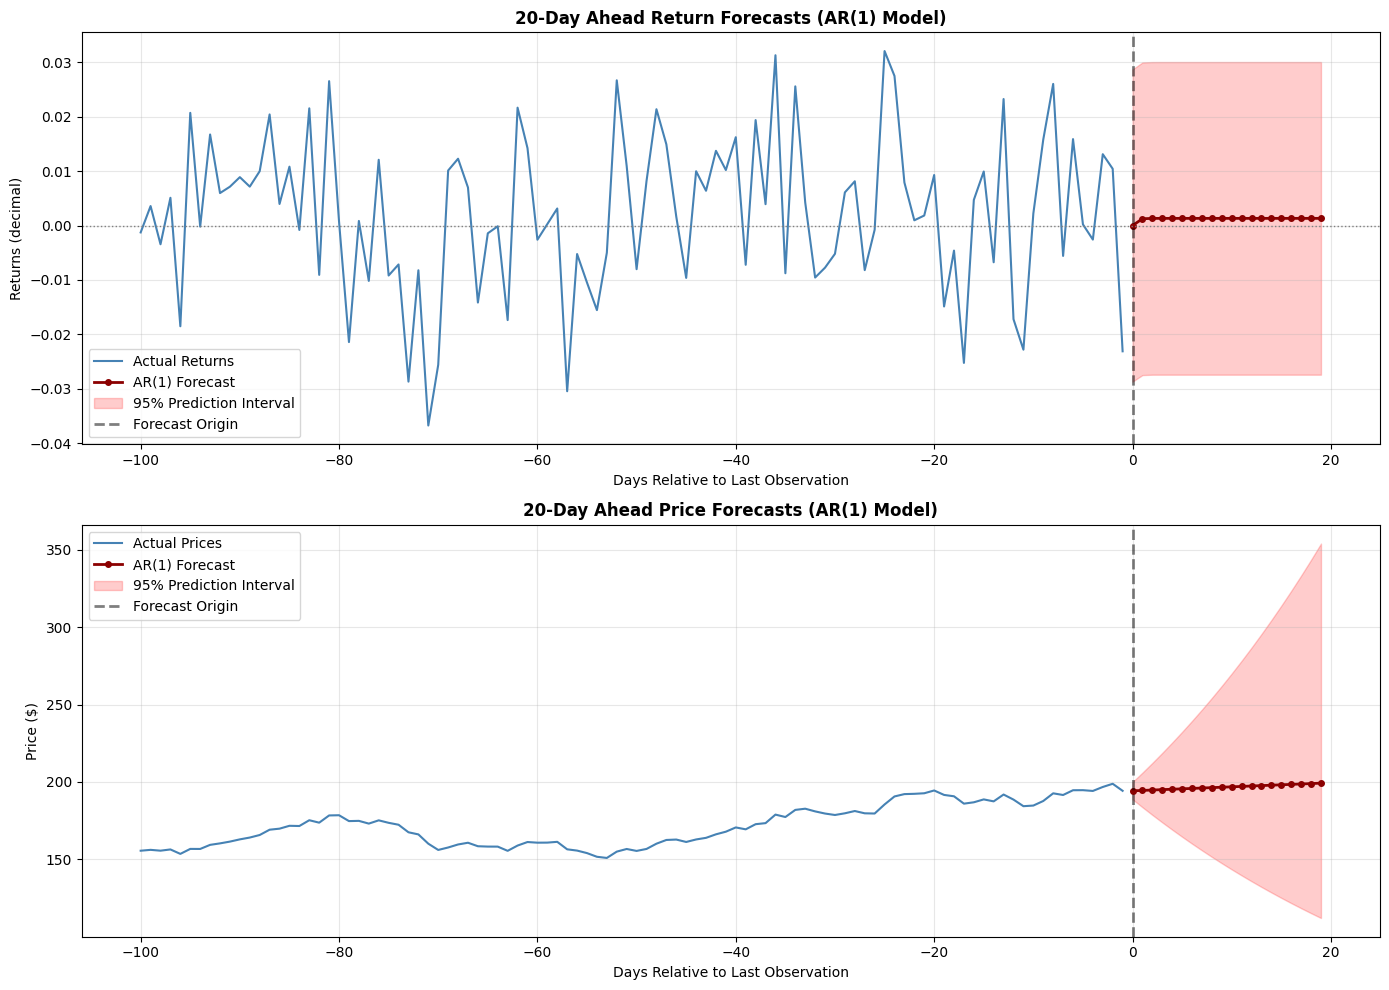

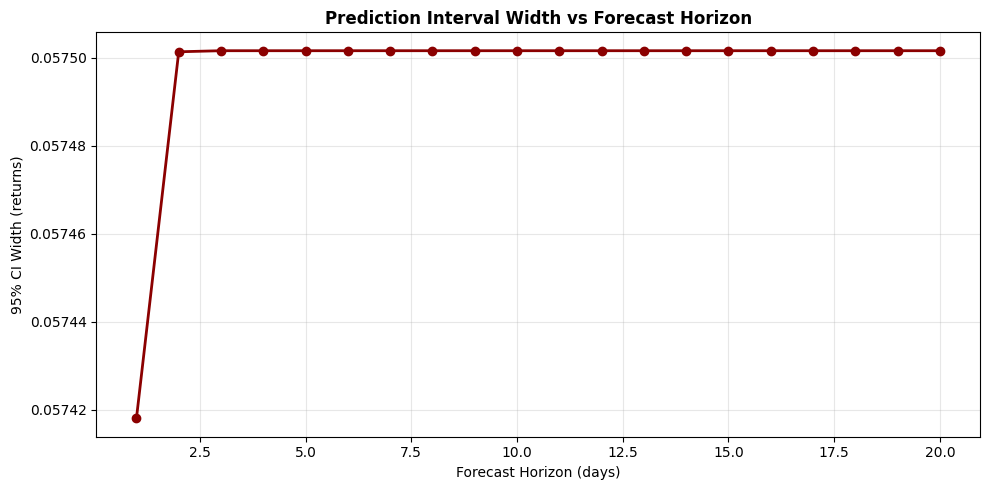

In [ ]:
print("\n" + "-" * 70)
print("B8: ARIMA Forecasting")
print("-" * 70)

# YOUR CODE:
# Using your best ARIMA model from B7:
#
# 1. Generate forecasts:
#    - 20-day ahead forecasts for returns
#    - Include prediction intervals
print("\n" + "=" * 70)
print("FITTING AR(1) MODEL FOR FORECASTING")
print("=" * 70)

forecast_model_order = (1, 0, 0)
forecast_model = ARIMA(returns_clean, order=forecast_model_order).fit()


# 2. Plot forecast:
#    - Last 100 days of actual returns
#    - 20-day forecast
#    - 95% prediction interval

forecast_steps = 20

# Get forecast with prediction intervals
forecast_result = forecast_model.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=0.05)  # 95% CI

print(f"\nForecast horizon: {forecast_steps} days")
print(f"Confidence level: 95%")

# Display first 10 and last 5 forecasts
print("\nReturn forecasts (decimal):")
print("-" * 80)
print(f"{'Day':>4} {'Forecast':>12} {'Lower 95%':>14} {'Upper 95%':>14} {'CI Width':>12}")
print("-" * 80)

for i in range(min(10, forecast_steps)):
    day = i + 1
    fc = forecast_mean.iloc[i]
    lower = forecast_ci.iloc[i, 0]
    upper = forecast_ci.iloc[i, 1]
    width = upper - lower
    print(f"{day:4d} {fc:12.6f} {lower:14.6f} {upper:14.6f} {width:12.6f}")

if forecast_steps > 10:
    print("  ...")
    for i in range(forecast_steps - 5, forecast_steps):
        day = i + 1
        fc = forecast_mean.iloc[i]
        lower = forecast_ci.iloc[i, 0]
        upper = forecast_ci.iloc[i, 1]
        width = upper - lower
        print(f"{day:4d} {fc:12.6f} {lower:14.6f} {upper:14.6f} {width:12.6f}")

print("\n" + "=" * 70)
print("PLOTTING FORECAST")
print("=" * 70)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Returns forecast
last_n = 100
actual_recent = returns_clean.iloc[-last_n:]

axes[0].plot(range(-last_n, 0), actual_recent.values, 
             linewidth=1.5, color='steelblue', label='Actual Returns')
axes[0].plot(range(0, forecast_steps), forecast_mean.values, 
             linewidth=2, color='darkred', marker='o', markersize=4, label='AR(1) Forecast')
axes[0].fill_between(range(0, forecast_steps), 
                      forecast_ci.iloc[:, 0].values, 
                      forecast_ci.iloc[:, 1].values,
                      color='red', alpha=0.2, label='95% Prediction Interval')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5, label='Forecast Origin')
axes[0].axhline(y=0, color='gray', linestyle=':', linewidth=1)
axes[0].set_title(f'20-Day Ahead Return Forecasts (AR(1) Model)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days Relative to Last Observation')
axes[0].set_ylabel('Returns (decimal)')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# 3. Convert return forecasts to price forecasts:
#    - Starting from last observed price
#    - price_{t+h} = price_t × exp(cumsum(return forecasts))

print("\n" + "=" * 70)
print("CONVERTING TO PRICE FORECASTS")
print("=" * 70)

# Starting price (last observed price)
last_price = df_stock['Price'].iloc[-1]
print(f"Last observed price (Day 0): ${last_price:.2f}")

# Method: price_{t+h} = price_t × exp(cumsum(return forecasts))
cumulative_returns = np.cumsum(forecast_mean.values)
price_forecast = last_price * np.exp(cumulative_returns)

# Confidence intervals for prices
cumulative_returns_lower = np.cumsum(forecast_ci.iloc[:, 0].values)
cumulative_returns_upper = np.cumsum(forecast_ci.iloc[:, 1].values)
price_lower = last_price * np.exp(cumulative_returns_lower)
price_upper = last_price * np.exp(cumulative_returns_upper)

print("\nPrice forecasts:")
print("-" * 80)
print(f"{'Day':>4} {'Price':>12} {'Lower 95%':>12} {'Upper 95%':>12} {'CI Width':>12}")
print("-" * 80)

for i in range(min(10, forecast_steps)):
    day = i + 1
    print(f"{day:4d} ${price_forecast[i]:11.2f} ${price_lower[i]:11.2f} "
          f"${price_upper[i]:11.2f} ${price_upper[i]-price_lower[i]:11.2f}")

if forecast_steps > 10:
    print("  ...")
    for i in range(forecast_steps - 5, forecast_steps):
        day = i + 1
        print(f"{day:4d} ${price_forecast[i]:11.2f} ${price_lower[i]:11.2f} "
              f"${price_upper[i]:11.2f} ${price_upper[i]-price_lower[i]:11.2f}")

actual_prices = df_stock['Price'].iloc[-last_n:]

axes[1].plot(range(-last_n, 0), actual_prices.values, 
             linewidth=1.5, color='steelblue', label='Actual Prices')
axes[1].plot(range(0, forecast_steps), price_forecast, 
             linewidth=2, color='darkred', marker='o', markersize=4, label='AR(1) Forecast')
axes[1].fill_between(range(0, forecast_steps), 
                      price_lower, 
                      price_upper,
                      color='red', alpha=0.2, label='95% Prediction Interval')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5, label='Forecast Origin')
axes[1].set_title(f'20-Day Ahead Price Forecasts (AR(1) Model)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Days Relative to Last Observation')
axes[1].set_ylabel('Price ($)')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# 4. Observe forecast behavior:
#    - Do return forecasts converge to zero?
#    - How does forecast uncertainty change with horizon?
#    - Why do prediction intervals widen?

print("\n" + "=" * 70)
print("FORECAST BEHAVIOR ANALYSIS")
print("=" * 70)

# Check if return forecasts converge to zero
print("\n1. DO RETURN FORECASTS CONVERGE TO ZERO?")
print("-" * 70)

print(f"Forecast at day 1:  {forecast_mean.iloc[0]:+.6f}")
print(f"Forecast at day 5:  {forecast_mean.iloc[4]:+.6f}")
print(f"Forecast at day 10: {forecast_mean.iloc[9]:+.6f}")
print(f"Forecast at day 20: {forecast_mean.iloc[19]:+.6f}")

print(f"\nAR(1) forecast formula: ŷ_{{t+h}} = φ^h × y_t")
if forecast_model_order[0] > 0:
    print(f"  where φ = {phi:.6f}")
    print(f"\nConvergence pattern:")
    print(f"  h=1:  φ^1  = {phi**1:.6f}")
    print(f"  h=5:  φ^5  = {phi**5:.6f}")
    print(f"  h=10: φ^10 = {phi**10:.6f}")
    print(f"  h=20: φ^20 = {phi**20:.6f}")
    print(f"\n✓ Forecasts decay exponentially to zero")
    print(f"✓ Rate of decay = φ = {phi:.4f} per step")
    print(f"✓ Half-life ≈ {-np.log(2)/np.log(abs(phi)):.1f} days" if abs(phi) < 1 and phi != 0 else "")

# Check forecast uncertainty
print("\n2. HOW DOES FORECAST UNCERTAINTY CHANGE WITH HORIZON?")
print("-" * 70)

ci_width = forecast_ci.iloc[:, 1] - forecast_ci.iloc[:, 0]

print(f"CI width at day 1:  {ci_width.iloc[0]:.6f}")
print(f"CI width at day 5:  {ci_width.iloc[4]:.6f}")
print(f"CI width at day 10: {ci_width.iloc[9]:.6f}")
print(f"CI width at day 20: {ci_width.iloc[19]:.6f}")

width_increase = (ci_width.iloc[-1] / ci_width.iloc[0] - 1) * 100
print(f"\nCI width increase from day 1 to day 20: {width_increase:.1f}%")

print("\n✓ Prediction intervals WIDEN with forecast horizon")

# Plot CI width over horizon
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, forecast_steps+1), ci_width.values, linewidth=2, marker='o', color='darkred')
ax.set_title('Prediction Interval Width vs Forecast Horizon', fontsize=12, fontweight='bold')
ax.set_xlabel('Forecast Horizon (days)')
ax.set_ylabel('95% CI Width (returns)')
ax.grid(True, alpha=0.3)
plt.tight_layout()

print("""
YES, the AR(1) return forecasts converge to zero very rapidly.      
Forecast uncertainty INCREASES with horizon, but stabilizes quickly.

Evidence from Image 2 (CI Width graph):
  • Day 1:  CI width ≈ 0.05742 (narrowest)
  • Day 2:  CI width jumps sharply to ≈ 0.05750
  • Day 3+: CI width plateaus at ≈ 0.05750 (constant)

      
Prediction intervals widen because forecast errors accumulate over time, 
though in this case the widening is minimal due to weak autocorrelation
""")


In [ ]:
cd path
git remote add origin https://github.com/YuqiaoLydia/ECON5140HM.git
git branch -M main
git push -u origin main

git add .
git commit -m "Update homework: "
git push

